# **EDA General**

##  **Diccionario de Datos - Ventas**

Este conjunto de datos contiene información transaccional de ventas, incluyendo detalles de productos, clientes, ubicación, vendedores y valores asociados a la facturación.

- **Número de registros**: 3,577,660
- **Periodo**: 2024-01-04 a 2025-12-27
- **Frecuencia:** Diaria

### Diccionario

| Variable            | Tipo de variable | Rango / Valores posibles | Descripción | Ejemplo | Observaciones |
|--------------------|------------------|--------------------------|-------------|---------|--------------|
| FECHA              | datetime         | 2024-08-24 a 2025-08-16 | Fecha de la transacción | 2024-08-24 | Es el índice del DataFrame |
| Bodega             | categórica       | Valores nominales (nombres de bodegas) | Lugar físico desde donde se realiza la venta | BODEGA CRA 16 | Baja cardinalidad |
| IDFactura          | numérica (int)   | Enteros positivos | Identificador único de la factura | 1909959 | Puede repetirse si hay múltiples productos por factura |
| IDProducto         | numérica (int)   | Enteros positivos | Identificador único del producto | 5243 | Relacionable con catálogo de productos |
| VlrUnitario        | numérica (float) | > 0 | Valor unitario del producto | 3666.6666 | Puede tener decimales |
| Producto           | categórica       | Nombres de productos | Descripción del producto vendido | GRIFLEX LAV/LVP 60 CM | Alta cardinalidad |
| ClaseProducto      | categórica       | Ej: Plomeria | Categoría general del producto | Plomeria | Útil para segmentación |
| TipoProducto       | categórica       | Ej: Grif. Accesorios | Subcategoría del producto | Grif. Accesorios | Más granular que clase |
| FlagImportado      | binaria (int)    | 0, 1 | Indica si el producto es importado | 0 | 1 = importado |
| Cliente            | categórica       | Nombres de clientes | Nombre del cliente | LUIS DANIEL RAMIREZ | Alta cardinalidad |
| Municipio          | categórica       | Municipios de Colombia | Municipio del cliente | BOGOTA DC KENNEDY SUR | Puede incluir localidad |
| Departamento       | categórica       | Departamentos de Colombia | Departamento del cliente | BOGOTA D.C. | Estandarizar nombres |
| Vendedor           | categórica       | Nombres de vendedores | Persona responsable de la venta | FREDY SABOYA | Alta cardinalidad |
| Facturado          | numérica (int)   | >= 0 | Cantidad facturada del producto | 12 | Puede representar unidades |
| BackOrder          | numérica (int)   | >= 0 | Cantidad pendiente por entregar | 0 | Importante para logística |
| ClaseVenta         | categórica       | Ej: NORMAL | Tipo de venta realizada | NORMAL | Puede incluir promociones |
| ProductoObsequio   | categórica       | Valores o NaN | Producto entregado como obsequio | NaN | Puede tener valores nulos |
| CantidadObsequio   | numérica (int)   | >= 0 | Cantidad de producto obsequiado | 0 | Relacionado con promociones |

## **Carga del Dataset**

In [2]:
# versiones
%%writefile requirements.txt
pandas==2.2.2
matplotlib==3.10.0
seaborn==0.13.2

Overwriting requirements.txt


In [3]:
# instalar versiones de librerias
!pip install -r requirements.txt

In [4]:
# Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from enum import unique
import matplotlib.dates as mdates

### Funciones propias

In [6]:
def analizar_nulos(df, columna):
    """
    Analiza la cantidad y porcentaje de valores nulos en una columna.

    Parámetros:
    - df: DataFrame
    - columna: nombre de la columna (str)
    """

    total_registros = len(df)
    cantidad_nulos = df[columna].isnull().sum()
    porcentaje_nulos = (cantidad_nulos / total_registros) * 100

    print("\n" + "="*50)
    print(f" VALORES NULOS - {columna.upper()}")
    print("="*50)
    print(f"Cantidad de valores nulos: {cantidad_nulos:,}")
    print(f"Porcentaje de nulos: {porcentaje_nulos:.2f}%")

In [7]:
def analizar_valores_unicos(df, columna, max_mostrar=20):
    """
    Muestra los valores únicos de una columna y su cantidad.

    Parámetros:
    - df: DataFrame
    - columna: nombre de la columna (str)
    - max_mostrar: número máximo de valores únicos a mostrar
    """

    valores_unicos = df[columna].unique()
    cantidad_unicos = len(valores_unicos)

    print("\n" + "="*50)
    print(f" VALORES ÚNICOS - {columna.upper()}")
    print("="*50)
    print(f"Cantidad de valores únicos: {cantidad_unicos:,}")

    print(f"\nPrimeros {min(max_mostrar, cantidad_unicos)} valores:")
    print(valores_unicos[:max_mostrar])

In [8]:
def eliminar_nulos_por_columna(df, columna, inplace=False):
    """
    Elimina los registros (filas) donde una columna específica tiene valores nulos.

    Parámetros:
    - df: DataFrame
    - columna: nombre de la columna (str)
    - inplace: si True, modifica el DataFrame original

    Retorna:
    - DataFrame limpio (si inplace=False)
    """

    total_antes = len(df)
    nulos = df[columna].isnull().sum()

    print("\n" + "="*50)
    print(f" ELIMINACIÓN DE NULOS - {columna.upper()}")
    print("="*50)
    print(f"Registros antes: {total_antes:,}")
    print(f"Registros con nulos en '{columna}': {nulos:,}")

    if inplace:
        df.dropna(subset=[columna], inplace=True)
        total_despues = len(df)
        print(f"Registros después: {total_despues:,}")
        print(f"Filas eliminadas: {total_antes - total_despues:,}")
    else:
        df_limpio = df.dropna(subset=[columna])
        total_despues = len(df_limpio)
        print(f"Filas eliminadas: {total_antes - total_despues:,}")
        return df_limpio

## **limpieza y Estandarización**

In [9]:
# Visualizar dataset
df = pd.read_csv('/content/drive/MyDrive/Trabajo de Grado JuanPablo/Datasets/Data_Set_05132026.csv', sep=';', on_bad_lines='skip')

# Conversión inicial
df['FECHA'] = pd.to_datetime(df['FECHA'], errors='coerce')

df.head(10)

/tmp/ipykernel_1863/2117760548.py:2: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Trabajo de Grado JuanPablo/Datasets/Data_Set_05132026.csv', sep=';', on_bad_lines='skip')


,FECHA,Semana,Bodega,IDFactura,IDProducto,VlrUnitario,Producto,ClaseProducto,DiasImportacion,TipoProducto,FlagImportado,Cliente,Municipio,Departamento,Vendedor,Facturado,BackOrder,ClaseVenta,ProductoObsequio,CantidadObsequio
0,2025-09-06,36,PALOQUEMAO,2071756,282,876.0,BUJE LAVAMANOS 1 1/2 CAUCHO PLASTGRIFOS,Griferias,NaN,Grif. Accesorios,0,SALOMON ALVARO BEJARANO URREGO,CUMARAL,META,CLAUDIA RODRIGUEZ,6.0,0.0,NORMAL,NaN,0.0
1,2024-11-07,45,PALOQUEMAO,1940864,1708,18950.0,TIJERA PODADORA BELLOTA 3501-18 7,Herramientas,15.0,Manual,0,LUCENIA CAMACHO JURADO,TABIO,CUNDINAMARCA,LEONARDO QUINTERO,2.0,0.0,NORMAL,NaN,0.0
2,2024-01-25,4,BODEGA CRA 16,1826114,8770,264060.0,ALAMBRE DE PUAS 12.5X350MTS CORSAN,Fijacion y Amarres,7.0,Fijacion y Amarres,0,WILLIAM STIVEN RODRIGUEZ AVILA,FACATATIVA,CUNDINAMARCA,KARINA RODRIGUEZ,1.0,0.0,NORMAL,NaN,0.0
3,2025-01-23,4,PALOQUEMAO,1971682,1364,1560.0,PVC SEMICODO 2 CXC LEO,Plomeria,8.0,Plom. Accesorios,0,MARTIN CAMILO FLOREZ,BOGOTA DC PUENTE ARANDA,BOGOTA D.C.,ALEXANDER JIMENEZ,4.0,0.0,NORMAL,NaN,0.0
4,2024-02-28,9,BODEGA CRA 16,1839937,5294,34700.0,CHEQUE CORTINA 1 GRIVAL 797170001,Plomeria,14.0,Plom. Accesorios,0,AGROFERRETERIA SANTANDERCITO S.A.S,SAN ANTONIO DEL TEQUENDAMA,CUNDINAMARCA,KARINA RODRIGUEZ,3.0,0.0,NORMAL,NaN,0.0
5,2024-02-29,9,PALOQUEMAO,1840030,3405,13400.0,CERRADURA ALCOBA MADERA CORONEL OSCURA DL-1043C,Seguridad,165.0,Cerrajeria,1,LUCENIA CAMACHO JURADO,TABIO,CUNDINAMARCA,LEONARDO QUINTERO,3.0,0.0,NORMAL,NaN,0.0
6,2025-09-25,39,PALOQUEMAO,2080836,11702,24680.0,SIKAFLEX UNIVERSAL GRIS X 300ML\t - 515119,Construccion,15.0,Construccion,0,MARTIN CAMILO FLOREZ,BOGOTA DC PUENTE ARANDA,BOGOTA D.C.,MILTON FLOREZ,1.0,0.0,NORMAL,NaN,0.0
7,2024-04-04,14,PALOQUEMAO,1852635,6317,280.0,ADAPTADOR ROSCADO HEMBRA DE 1/2 PAVCO 2900714,Plomeria,5.0,Plom. Accesorios,0,JEIMY LORENA BUITRAGO CASTRO,FACATATIVA,CUNDINAMARCA,ODUAR HARVEY CARDENAS RODRIGUEZ,100.0,0.0,NORMAL,NaN,0.0
8,2024-05-23,21,PALOQUEMAO,1872306,13269,60690.0,CINTA MULTISEAL 33 CM X 5MT TEXSA,Pinturas Y Adhesivos,8.0,Adh. Cinta,0,CENTRO MAYORISTA DE PINTURAS Y FERRETERIA SAS,CAJICA,CUNDINAMARCA,ALBERTO GUTIERREZ,3.0,0.0,NORMAL,NaN,0.0
9,2025-07-23,30,BODEGA CRA 16,2050744,8719,4300.0,SIFON ESCUALIZABLE KAUDAL DL-1231,Griferias,120.0,Grif. Accesorios,1,WILLIAM STIVEN RODRIGUEZ AVILA,FACATATIVA,CUNDINAMARCA,KARINA RODRIGUEZ,10.0,0.0,NORMAL,NaN,0.0


In [10]:
fecha_inicial = df['FECHA'].min()
fecha_final = df['FECHA'].max()

print(f"Fecha inicial del dataset: {fecha_inicial.strftime('%Y-%m-%d')}")
print(f"Fecha final del dataset: {fecha_final.strftime('%Y-%m-%d')}")

Fecha inicial del dataset: 2024-01-04
Fecha final del dataset: 2025-12-31


In [11]:
# Cantidad de filas y columnas
df.shape

(3655590, 20)

In [12]:
# Transformación de variables
df['FECHA'] = pd.to_datetime(df['FECHA'], errors='coerce')
df['Bodega'] = df['Bodega'].astype('category')
df['Producto'] = df['Producto'].astype('category')
df['ClaseProducto'] = df['ClaseProducto'].astype('category')
df['TipoProducto'] = df['TipoProducto'].astype('category')
df['Cliente'] = df['Cliente'].astype('category')
df['Municipio'] = df['Municipio'].astype('category')
df['Departamento'] = df['Departamento'].astype('category')
df['IDFactura'] = df['IDFactura'].astype('int64')

# Limpieza segura para columnas numéricas que podrían venir como string
for col in ['Facturado', 'BackOrder', 'CantidadObsequio']:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace(',', '.').astype(float).fillna(0).astype('int64')
    else:
        df[col] = df[col].fillna(0).astype('int64')

df['ClaseVenta'] = df['ClaseVenta'].astype('category')
df['ProductoObsequio'] = df['ProductoObsequio'].astype('category')

In [13]:
# Tipo de variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3655590 entries, 0 to 3655589
Data columns (total 20 columns):
 #   Column            Dtype         
---  ------            -----         
 0   FECHA             datetime64[ns]
 1   Semana            int64         
 2   Bodega            category      
 3   IDFactura         int64         
 4   IDProducto        int64         
 5   VlrUnitario       float64       
 6   Producto          category      
 7   ClaseProducto     category      
 8   DiasImportacion   float64       
 9   TipoProducto      category      
 10  FlagImportado     int64         
 11  Cliente           category      
 12  Municipio         category      
 13  Departamento      category      
 14  Vendedor          object        
 15  Facturado         int64         
 16  BackOrder         int64         
 17  ClaseVenta        category      
 18  ProductoObsequio  category      
 19  CantidadObsequio  int64         
dtypes: category(9), datetime64[ns](1), float64(2),

In [15]:
# Dataset transformado
df.head()

,FECHA,Semana,Bodega,IDFactura,IDProducto,VlrUnitario,Producto,ClaseProducto,DiasImportacion,TipoProducto,FlagImportado,Cliente,Municipio,Departamento,Vendedor,Facturado,BackOrder,ClaseVenta,ProductoObsequio,CantidadObsequio
0,2025-09-06,36,PALOQUEMAO,2071756,282,876.0,BUJE LAVAMANOS 1 1/2 CAUCHO PLASTGRIFOS,Griferias,NaN,Grif. Accesorios,0,SALOMON ALVARO BEJARANO URREGO,CUMARAL,META,CLAUDIA RODRIGUEZ,6,0,NORMAL,NaN,0
1,2024-11-07,45,PALOQUEMAO,1940864,1708,18950.0,TIJERA PODADORA BELLOTA 3501-18 7,Herramientas,15.0,Manual,0,LUCENIA CAMACHO JURADO,TABIO,CUNDINAMARCA,LEONARDO QUINTERO,2,0,NORMAL,NaN,0
2,2024-01-25,4,BODEGA CRA 16,1826114,8770,264060.0,ALAMBRE DE PUAS 12.5X350MTS CORSAN,Fijacion y Amarres,7.0,Fijacion y Amarres,0,WILLIAM STIVEN RODRIGUEZ AVILA,FACATATIVA,CUNDINAMARCA,KARINA RODRIGUEZ,1,0,NORMAL,NaN,0
3,2025-01-23,4,PALOQUEMAO,1971682,1364,1560.0,PVC SEMICODO 2 CXC LEO,Plomeria,8.0,Plom. Accesorios,0,MARTIN CAMILO FLOREZ,BOGOTA DC PUENTE ARANDA,BOGOTA D.C.,ALEXANDER JIMENEZ,4,0,NORMAL,NaN,0
4,2024-02-28,9,BODEGA CRA 16,1839937,5294,34700.0,CHEQUE CORTINA 1 GRIVAL 797170001,Plomeria,14.0,Plom. Accesorios,0,AGROFERRETERIA SANTANDERCITO S.A.S,SAN ANTONIO DEL TEQUENDAMA,CUNDINAMARCA,KARINA RODRIGUEZ,3,0,NORMAL,NaN,0


### Bodega

In [16]:
analizar_valores_unicos(df, 'Bodega')


 VALORES ÚNICOS - BODEGA
Cantidad de valores únicos: 5

Primeros 5 valores:
['PALOQUEMAO', 'BODEGA CRA 16', 'MERCADOLIBRE', 'HOGAR', 'ZPRINCIPAL']
Categories (5, object): ['BODEGA CRA 16', 'HOGAR', 'MERCADOLIBRE', 'PALOQUEMAO', 'ZPRINCIPAL']


In [17]:
analizar_nulos(df, 'Bodega')


 VALORES NULOS - BODEGA
Cantidad de valores nulos: 0
Porcentaje de nulos: 0.00%


### ID Factura y Producto

Se tienen 6,204 valores unicos de IDProducto, lo que quiere decir que se tienen más de 6,000 SKU's de productos que analizar.

In [18]:
analizar_valores_unicos(df, 'IDFactura')


 VALORES ÚNICOS - IDFACTURA
Cantidad de valores únicos: 301,018

Primeros 20 valores:
[2071756 1940864 1826114 1971682 1839937 1840030 2080836 1852635 1872306
 2050744 2083449 1852517 1858710 1952166 1868702 1998541 1843900 2096411
 1848831 2039154]


In [19]:
analizar_nulos(df, 'IDFactura')


 VALORES NULOS - IDFACTURA
Cantidad de valores nulos: 0
Porcentaje de nulos: 0.00%


In [20]:
analizar_valores_unicos(df, 'IDProducto')


 VALORES ÚNICOS - IDPRODUCTO
Cantidad de valores únicos: 6,401

Primeros 20 valores:
[  282  1708  8770  1364  5294  3405 11702  6317 13269  8719  1456  2694
  5562  3509  9940  1433  1618  8022  7117 10444]


In [21]:
analizar_nulos(df, 'IDProducto')


 VALORES NULOS - IDPRODUCTO
Cantidad de valores nulos: 0
Porcentaje de nulos: 0.00%


### VlrUnitario

Al tener menos del 0,01% de datos nulos en esta variable es posible eliminarlo sin perder calidad del conjunto de datos

In [22]:
analizar_nulos(df, 'VlrUnitario')


 VALORES NULOS - VLRUNITARIO
Cantidad de valores nulos: 7
Porcentaje de nulos: 0.00%


In [23]:
df = eliminar_nulos_por_columna(df, 'VlrUnitario')


 ELIMINACIÓN DE NULOS - VLRUNITARIO
Registros antes: 3,655,590
Registros con nulos en 'VlrUnitario': 7
Filas eliminadas: 7


In [24]:
# Análisis de VlrUnitario = 0
total_registros = len(df)
cantidad_VlrUnitario_cero = (df['VlrUnitario'] == 0).sum()
porcentaje_VlrUnitario_cero = (cantidad_VlrUnitario_cero / total_registros) * 100

#Mostrar resultados
print("\n" + "="*80)
print("RESGISTROS CVlrUnitario = 0")
print("="*80)
print(f"Total de registros: {total_registros:,}")
print(f"VlrUnitario igual a cero: {cantidad_VlrUnitario_cero:,}")
print(f"Porcentaje: {porcentaje_VlrUnitario_cero:.2f}%")


RESGISTROS CVlrUnitario = 0
Total de registros: 3,655,583
VlrUnitario igual a cero: 18
Porcentaje: 0.00%


### Producto (Clase y Tipo)

In [25]:
analizar_valores_unicos(df, 'ClaseProducto')


 VALORES ÚNICOS - CLASEPRODUCTO
Cantidad de valores únicos: 19

Primeros 19 valores:
['Griferias', 'Herramientas', 'Fijacion y Amarres', 'Plomeria', 'Seguridad', ..., ' NA/ND', 'Licitaciones', 'Hogar Complementario', 'Administrativo', 'Catalogo de Puntos']
Length: 19
Categories (19, object): [' NA/ND', 'Abrasivos', 'Acabados', 'Administrativo', ...,
                          'Proteccion Personal', 'Quimicos', 'Seguridad', 'Variedades']


In [26]:
analizar_nulos(df, 'ClaseProducto')


 VALORES NULOS - CLASEPRODUCTO
Cantidad de valores nulos: 0
Porcentaje de nulos: 0.00%


#### **Listado de categorías**

* NA/ND | Abrasivos | Acabados | Administrativo | Catalogo de Puntos  
* Construccion | Electricos | ExcluidosLista | Fijacion y Amarres | Griferias  
* Herramientas | Hogar Complementario | Licitaciones | Pinturas Y Adhesivo  
* Plomeria | Proteccion Personal | Quimicos | Seguridad | Variedades  

---

Para este proyecto, y en conjunto con el equipo de analítica de datos y la gerencia comercial, se decidió dejar por fuera del análisis las siguientes categorías:

- **Administrativo**
- **Catálogo de Puntos**
- **ExcluidosLista**
- **Licitaciones**

El análisis se enfoca únicamente en el catálogo de productos dirigido a clientes regulares o frecuentes, entendido como aquellos que realizan **al menos dos compras en un periodo de tres meses**.

Las categorías excluidas corresponden principalmente a líneas de negocio que no hacen parte del consumo habitual, ya sea porque:

- Son transacciones ocasionales y predecibles
- No reflejan la demanda recurrente de los clientes  
- Pertenecen a dinámicas comerciales diferentes  

#### **IMPORTANTE**

In [27]:
analizar_valores_unicos(df, 'TipoProducto')


 VALORES ÚNICOS - TIPOPRODUCTO
Cantidad de valores únicos: 43

Primeros 20 valores:
['Grif. Accesorios', 'Manual', 'Fijacion y Amarres', 'Plom. Accesorios', 'Cerrajeria', ..., 'Variedades', 'Pint. Vinilo', 'Tubo Ventilacion', 'Seg. Complementarios', 'Herr. Accesorios']
Length: 20
Categories (43, object): [' NA/ND', 'Adh.  Cinta', 'Adh.  Complementarios', 'Adh.  Pegantes',
                          ..., 'Tubo Presion', 'Tubo Sanitario', 'Tubo Ventilacion',
                          'Variedades']


In [28]:
analizar_nulos(df, 'TipoProducto')


 VALORES NULOS - TIPOPRODUCTO
Cantidad de valores nulos: 0
Porcentaje de nulos: 0.00%


In [29]:
# Validar si un TipoProducto está asociado a varias ClaseProducto
conteo_clases_por_tipo = df.groupby('TipoProducto')['ClaseProducto'].nunique()

# Filtrar quienes tengan más de una clase
tipos_inconsistentes = conteo_clases_por_tipo[conteo_clases_por_tipo > 1]

if not tipos_inconsistentes.empty:
    print("\n" + "=" * 90)
    print("TIPOS DE PRODUCTO ASOCIADOS A MÁS DE UNA CLASE DE PRODUCTO")
    print("=" * 90)

    for tipo, cantidad_clases in tipos_inconsistentes.sort_values(ascending=False).items():
        clases_asociadas = (
            df[df['TipoProducto'] == tipo]['ClaseProducto']
            .dropna()
            .unique()
            .tolist()
        )

        # Convertir lista a texto horizontal
        clases_str = " | ".join(sorted(clases_asociadas))

        print(f"\nTipoProducto: {tipo}")
        print(f"Cantidad de clases: {cantidad_clases}")
        print(f"Clases asociadas: {clases_str}")

else:
    print("\nNo se encontraron tipos de producto que pertenezcan a más de una clase.")


TIPOS DE PRODUCTO ASOCIADOS A MÁS DE UNA CLASE DE PRODUCTO


/tmp/ipykernel_1863/339073409.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conteo_clases_por_tipo = df.groupby('TipoProducto')['ClaseProducto'].nunique()



TipoProducto: Construccion
Cantidad de clases: 9
Clases asociadas: Acabados | Administrativo | Construccion | ExcluidosLista | Griferias | Hogar Complementario | Licitaciones | Pinturas Y Adhesivos | Plomeria

TipoProducto: Grif. Accesorios
Cantidad de clases: 7
Clases asociadas: Construccion | Griferias | Hogar Complementario | Licitaciones | Pinturas Y Adhesivos | Plomeria | Variedades

TipoProducto: Fijacion y Amarres
Cantidad de clases: 5
Clases asociadas: Construccion | Fijacion y Amarres | Griferias | Licitaciones | Plomeria

TipoProducto: Grifos
Cantidad de clases: 5
Clases asociadas: Acabados | Construccion | Fijacion y Amarres | Griferias | Hogar Complementario

TipoProducto: Plom. Accesorios
Cantidad de clases: 5
Clases asociadas: Griferias | Licitaciones | Pinturas Y Adhesivos | Plomeria | Quimicos

TipoProducto:  NA/ND
Cantidad de clases: 4
Clases asociadas:  NA/ND | Administrativo | Catalogo de Puntos | Seguridad

TipoProducto: Variedades
Cantidad de clases: 4
Clases asoc

- Confirmar si **“Tipo de producto”** corresponde efectivamente a una **subcategoría de “Clase de producto”**.
- En caso de ser así, revisar si tiene sentido desde la lógica de negocio que un mismo **tipo de producto** pertenezca a **más de una clase**.

Si esto no es consistente:

- Validar con el equipo cómo debe ser la **agrupación correcta** de los tipos de producto.
- Alinear esta estructura con la lógica real del portafolio antes de continuar con el análisis.


**Decisiones a definir antes de excluir categorías**

Previo a eliminar las clases que no hacen parte del alcance, es clave definir cómo se manejarán esos registros:

- ¿Se deben **eliminar completamente** del dataset?
- ¿O se deben **reagrupar** dentro de otras clases de producto?

En caso de reagrupar, se debe establecer un criterio claro, por ejemplo:

- Asignación basada en la **naturaleza del producto**
- Reglas definidas por el **negocio**
- Estrategias de **balanceo de categorías** (ej. agrupar en clases con menor volumen)


**Datos adicionales**

- podrian proporcionarnos la marca o linea de producto a la que pertenece, ej: marcas de la categoria de griferia: Grival, Gricol, corona, etc. O linea economia, media, premium, etc. (para ver correlaciones entre productos de una misma categoria, y como incide en la demanda "")

### FlagImportado

In [30]:
analizar_nulos(df, 'FlagImportado')


 VALORES NULOS - FLAGIMPORTADO
Cantidad de valores nulos: 0
Porcentaje de nulos: 0.00%


/tmp/ipykernel_1863/1262306002.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


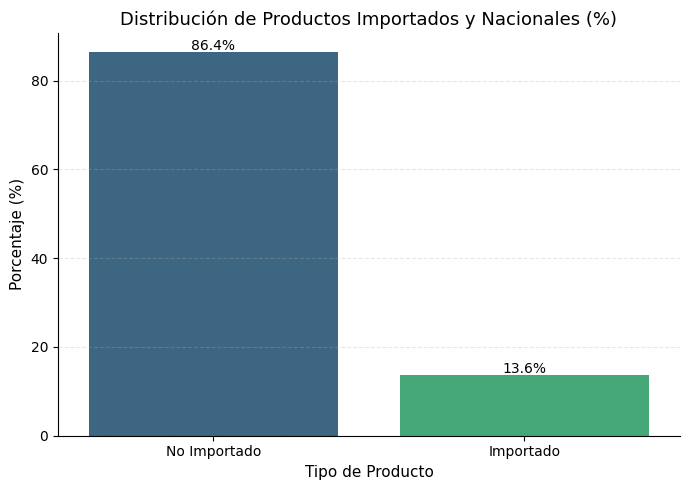

In [31]:
# Distribución de Importados

# Calcular cantidades y porcentajes
counts = df['FlagImportado'].value_counts()
percentages = df['FlagImportado'].value_counts(normalize=True) * 100

# Crear gráfico
plt.figure(figsize=(7, 5))

sns.barplot(
    x=percentages.index,
    y=percentages.values,
    palette='viridis'
)

# Etiquetas
plt.title('Distribución de Productos Importados y Nacionales (%)', fontsize=13)
plt.xlabel('Tipo de Producto', fontsize=11)
plt.ylabel('Porcentaje (%)', fontsize=11)
plt.xticks([0, 1], ['No Importado', 'Importado'])

# Valor barra
for i, v in enumerate(percentages.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

### Cliente

In [32]:
analizar_valores_unicos(df, 'Cliente')


 VALORES ÚNICOS - CLIENTE
Cantidad de valores únicos: 18,926

Primeros 20 valores:
['SALOMON ALVARO BEJARANO URREGO', 'LUCENIA CAMACHO JURADO', 'WILLIAM STIVEN RODRIGUEZ AVILA', 'MARTIN CAMILO FLOREZ', 'AGROFERRETERIA SANTANDERCITO S.A.S', ..., 'HECTOR JULIO CASTILLO CABRERA', 'LUIS ARMANDO CONDE', 'ALEJANDRO CELIS LOPEZ', 'MILTON ARNULFO CUBILLOS NEIRA', 'EDUARD ALBERTO LOZANO GOMEZ']
Length: 20
Categories (18926, object): [' CLIENTE MOSTRADOR', ' FUNDACION GRUPO CONSERVA',
                             ' Michael Jarvis Gordon', ' OSCAR DAVID CASTAÑO PINEDA', ..., 'steven White',
                             'ÁLVARO ENRIQUE BRAVO PULIDO', 'ÉLITE CONSTRUCCIONES C&R S.A.S.', 'ÓSCAR ÁLVAREZ']


In [33]:
analizar_nulos(df, 'Cliente')


 VALORES NULOS - CLIENTE
Cantidad de valores nulos: 0
Porcentaje de nulos: 0.00%


In [34]:
# ==========================================================
# Limpieza de clientes atípicos
# ==========================================================

# 1. Convertir a string, quitar espacios y pasar a mayúsculas
df['Cliente'] = df['Cliente'].astype(str).str.strip().str.upper()

# 2. Definir palabras o patrones atípicos
# Se eliminarán todos los registros cuyo cliente contenga alguno de estos textos,
# incluso si tienen más palabras, por ejemplo:
# 'CONTADOR AR', 'VENTAS CONTADOR GH', 'CLIENTE MOSTRADOR RC ZONA SUR'
patrones_atipicos = [
    'MOSTRADOR',
    'CONTADOR',
    'CONTADO'
]

# 3. Construir patrón regex
patron_regex = '|'.join(patrones_atipicos)

# 4. Identificar registros atípicos
mask_atipicos = df['Cliente'].str.contains(patron_regex, case=False, na=False, regex=True)

# 5. Calcular cantidad y porcentaje de registros atípicos
cantidad_atipicos = mask_atipicos.sum()
total_registros = len(df)
porcentaje_atipicos = (cantidad_atipicos / total_registros) * 100

print("\n" + "=" * 80)
print("ANÁLISIS DE CLIENTES ATÍPICOS")
print("=" * 80)
print(f"Cantidad de registros atípicos: {cantidad_atipicos:,}")
print(f"Porcentaje sobre el total: {porcentaje_atipicos:.2f}%")

# 6. Mostrar ejemplos de clientes detectados
clientes_detectados = df.loc[mask_atipicos, 'Cliente'].dropna().unique().tolist()

print("\nClientes detectados para eliminación:")
print(" | ".join(sorted(clientes_detectados[:30])))

if len(clientes_detectados) > 30:
    print(f"... y {len(clientes_detectados) - 30} valores más")

# 7. Eliminar los registros atípicos
df = df.loc[~mask_atipicos].copy()

# 8. Convertir nuevamente a category
df['Cliente'] = df['Cliente'].astype('category')


ANÁLISIS DE CLIENTES ATÍPICOS
Cantidad de registros atípicos: 220,427
Porcentaje sobre el total: 6.03%

Clientes detectados para eliminación:
CLIENTE MOSTRADOR | CLIENTE MOSTRADOR AJ | CLIENTE MOSTRADOR BEE | CLIENTE MOSTRADOR EP | CLIENTE MOSTRADOR FS | CLIENTE MOSTRADOR KR | CLIENTE MOSTRADOR LS | CLIENTE MOSTRADOR MAR | CLIENTE MOSTRADOR MF | CLIENTE MOSTRADOR ML | CLIENTE MOSTRADOR MS | CLIENTE MOSTRADOR NC | CLIENTE MOSTRADOR PD | CLIENTE MOSTRADOR RC | CLIENTE MOSTRADOR YA | CLIENTE MOSTRADOR YR | VENTAS CONTADO AR | VENTAS CONTADOR AG | VENTAS CONTADOR AS | VENTAS CONTADOR CR | VENTAS CONTADOR DG | VENTAS CONTADOR FM | VENTAS CONTADOR FR | VENTAS CONTADOR JB | VENTAS CONTADOR LQ | VENTAS CONTADOR OC | VENTAS CONTADOR RM | VENTAS CONTADOR WS | VENTAS CONTADOR WT | VENTAS CONTADOR WV
... y 2 valores más


#### **IMPORTANTE**

Antes de continuar con el análisis, es necesario validar el impacto de los **clientes eliminados** dentro del dataset:

- Verificar que no representen un **porcentaje significativo** del total de datos.
- Confirmar que efectivamente **no hacen parte del alcance del proyecto**.

Si se identifica que estos clientes tienen un peso importante en el dataset, considerar su **unificación bajo un único vendedor o categoría genérica**.

### Municipio y Departamento

In [35]:
analizar_valores_unicos(df, 'Departamento')


 VALORES ÚNICOS - DEPARTAMENTO
Cantidad de valores únicos: 32

Primeros 20 valores:
['META', 'CUNDINAMARCA', 'BOGOTA D.C.', 'BOYACA', 'HUILA', ..., 'RISARALDA', 'MAGDALENA', 'CAUCA', 'ATLANTICO', 'NORTE DE SANTANDER']
Length: 20
Categories (32, object): ['AMAZONAS', 'ANTIOQUIA', 'ARAUCA', 'ATLANTICO', ..., 'TOLIMA', 'VALLE',
                          'VAUPES', 'VICHADA']


In [36]:
analizar_nulos(df, 'Departamento')


 VALORES NULOS - DEPARTAMENTO
Cantidad de valores nulos: 0
Porcentaje de nulos: 0.00%


In [37]:
analizar_valores_unicos(df, 'Municipio')


 VALORES ÚNICOS - MUNICIPIO
Cantidad de valores únicos: 603

Primeros 20 valores:
['CUMARAL', 'TABIO', 'FACATATIVA', 'BOGOTA DC PUENTE ARANDA', 'SAN  ANTONIO DEL  TEQUENDAMA', ..., 'VILLAPINZON', 'ICONONZO', 'RESTREPO', 'PAZ DE ARIPORO', 'FLORENCIA']
Length: 20
Categories (603, object): ['ACACIAS', 'ACEVEDO', 'ACHI', 'AGRADO', ..., 'ZARZAL', 'ZETAQUIRA',
                           'ZIPACON', 'ZIPAQUIRA']


#### Importante

Considerar cambiar el nombre de variable, por zona  **(al tener algunos municipios segmentandos en zonas, ej: BOGOTA SANTA FE, BOGOTA, USME, etc.)**

In [38]:
analizar_nulos(df, 'Municipio')


 VALORES NULOS - MUNICIPIO
Cantidad de valores nulos: 0
Porcentaje de nulos: 0.00%


### Vendedor

In [39]:
analizar_nulos(df, 'Vendedor')


 VALORES NULOS - VENDEDOR
Cantidad de valores nulos: 0
Porcentaje de nulos: 0.00%


In [40]:
analizar_valores_unicos(df, 'Vendedor')


 VALORES ÚNICOS - VENDEDOR
Cantidad de valores únicos: 50

Primeros 20 valores:
['CLAUDIA RODRIGUEZ' 'LEONARDO QUINTERO' 'KARINA RODRIGUEZ'
 'ALEXANDER JIMENEZ' 'MILTON FLOREZ' 'ODUAR HARVEY CARDENAS RODRIGUEZ'
 'ALBERTO GUTIERREZ' 'MARCO LUQUE' 'EVER PEREZ' 'WILMER ARGUMEDO'
 'COMERCIAL APLICATIVO' 'NELSON CESPEDES' 'FELIPE SANCHEZ'
 'MARIA FERNANDA SUAREZ PARRA' 'WILMER TAVERA' 'RUBIEL MUÑOZ'
 'FREDY SABOYA' 'YESSIKA AMAYA' 'ARNOLD RIOS' 'CARLOS ARIAS']


In [41]:
# Porcentaje de venta por vendedor
if not pd.api.types.is_numeric_dtype(df['VlrUnitario']):
    df['VlrUnitario'] = (
        df['VlrUnitario']
        .astype(str)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )

if not pd.api.types.is_numeric_dtype(df['Facturado']):
    df['Facturado'] = (
        df['Facturado']
        .astype(str)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )

# Crear variable de venta total
df['VentaTotal'] = df['VlrUnitario'] * df['Facturado']

# Calcular valores
ventas_por_vendedor = df.groupby('Vendedor', observed=False)['VentaTotal'].sum()
total_ventas = df['VentaTotal'].sum()
porcentaje_ventas = (ventas_por_vendedor / total_ventas) * 100
porcentaje_ventas = porcentaje_ventas.sort_values(ascending=False)

# 8. Mostrar resultados
print("\n" + "="*80)
print("PORCENTAJE DE VENTAS TOTALES $$$ POR VENDEDOR")
print("="*80)
for vendedor, porcentaje in porcentaje_ventas.items():
    print(f"{vendedor:35} → {porcentaje:6.2f}%")


PORCENTAJE DE VENTAS TOTALES $$$ POR VENDEDOR
NELSON CESPEDES                     →  11.73%
EVER PEREZ                          →   5.59%
FREDY SABOYA                        →   5.25%
ALBERTO GUTIERREZ                   →   4.85%
WILMER TAVERA                       →   4.59%
KARINA RODRIGUEZ                    →   4.29%
ODUAR HARVEY CARDENAS RODRIGUEZ     →   4.25%
WILLIAN VANEGAS                     →   3.79%
DAYANNE GONZALEZ                    →   3.75%
 MOSTRADOR                          →   3.72%
LEONARDO QUINTERO                   →   3.60%
JAIVER BEDOYA                       →   3.56%
FELIPE SANCHEZ                      →   3.50%
CARLOS ARIAS                        →   3.07%
ANDRES SANCHEZ                      →   3.00%
MARCO LUQUE                         →   2.70%
MILTON FLOREZ                       →   2.64%
CLAUDIA RODRIGUEZ                   →   2.35%
WILLIAM SABOYA                      →   2.32%
FIDEL MEDINA                        →   2.31%
YIMAR REYES                      

In [42]:
def eliminar_vendedores_no_validos(df, columna='Vendedor'):
    """
    Elimina registros de vendedores que no representan ventas reales,
    como administrativos, mostrador, marketplace o transferencias.

    Parámetros:
    - df: DataFrame
    - columna: nombre de la columna de vendedores

    Retorna:
    - DataFrame limpio
    """

    # Estandarizar texto
    df[columna] = df[columna].astype(str).str.strip().str.upper()

    # Patrones a eliminar (reglas de negocio)
    patrones_excluir = [
        'MOSTRADOR',
        'MERCADO LIBRE',
        'LICITACIONES',
        'ADMINISTRATIVO',
        'MGIL-NOUSAR',
        'TRANSFERENCIAS'
    ]

    # Crear patrón regex
    patron_regex = '|'.join(patrones_excluir)

    # Identificar registros a eliminar
    mask_excluir = df[columna].str.contains(patron_regex, na=False, regex=True)

    # Métricas antes de eliminar
    total = len(df)
    cantidad_excluir = mask_excluir.sum()
    porcentaje = (cantidad_excluir / total) * 100

    print("\n" + "="*80)
    print("LIMPIEZA DE VENDEDORES NO VÁLIDOS")
    print("="*80)
    print(f"Registros a eliminar: {cantidad_excluir:,}")
    print(f"Porcentaje del total: {porcentaje:.2f}%")

    # Mostrar ejemplos
    vendedores_detectados = df.loc[mask_excluir, columna].unique().tolist()
    print("\nVendedores detectados:")
    print(" | ".join(sorted(vendedores_detectados[:20])))

    if len(vendedores_detectados) > 20:
        print(f"... y {len(vendedores_detectados) - 20} más")

    # Eliminar registros
    df_limpio = df.loc[~mask_excluir].copy()

    print("\nRegistros después de la limpieza:", f"{len(df_limpio):,}")

    return df_limpio

In [43]:
df = eliminar_vendedores_no_validos(df)


LIMPIEZA DE VENDEDORES NO VÁLIDOS
Registros a eliminar: 23,383
Porcentaje del total: 0.68%

Vendedores detectados:
ADMINISTRATIVO JURIDICO | LICITACIONES | MERCADO LIBRE | MGIL-NOUSAR | MOSTRADOR | TRANSFERENCIAS ABRACOL | TRANSFERENCIAS ALGRECO | TRANSFERENCIAS FIBERGLASS | TRANSFERENCIAS HENKEL | TRANSFERENCIAS PCP

Registros después de la limpieza: 3,411,773


#### **Importante**

Los registros asociados a los vendedores incluidos en la lista indicada fueron eliminados considerando lo siguiente:

- Su participación dentro del dataset es **inferior al 1%**, por lo que su exclusión no afecta de manera significativa la calidad ni la representatividad de los datos.
- No hacen parte del alcance del proyecto, el cual está enfocado en **clientes frecuentes**, es decir, aquellos que cuentan con un **vendedor asignado de forma regular**.

Adicionalmente, categorías como **transferencias, Mercado Libre, mostrador, administración y licitaciones**, aunque hacen parte de la demanda total, presentan limitaciones para este análisis:

- No es posible determinar con claridad si corresponden a **clientes frecuentes** o a demanda ocasional.
- En algunos casos, como **licitaciones**, su comportamiento es **atípico** y puede introducir ruido en los modelos, además de ser fácilmente predecible.

**Nota:** Validar con el equipo que el proceso de limpieza de esta variable es adecuado

### Facturado y BackOrder

In [44]:
analizar_nulos(df, 'Facturado')


 VALORES NULOS - FACTURADO
Cantidad de valores nulos: 0
Porcentaje de nulos: 0.00%


In [45]:
analizar_valores_unicos(df, 'Facturado')


 VALORES ÚNICOS - FACTURADO
Cantidad de valores únicos: 601

Primeros 20 valores:
[  6   2   1   4   3 100  10  20  12  50  30   5  15   8   0  24  25  96
  18   7]


In [46]:
# Análisis de Facturado = 0
total_registros = len(df)
cantidad_facturado_cero = (df['Facturado'] == 0).sum()
porcentaje_facturado_cero = (cantidad_facturado_cero / total_registros) * 100

#Mostrar resultados
print("\n" + "="*80)
print("RESGISTROS CON FACTURADO = 0")
print("="*80)
print(f"Total de registros: {total_registros:,}")
print(f"Facturado igual a cero: {cantidad_facturado_cero:,}")
print(f"Porcentaje: {porcentaje_facturado_cero:.2f}%")


RESGISTROS CON FACTURADO = 0
Total de registros: 3,411,773
Facturado igual a cero: 99,586
Porcentaje: 2.92%


In [47]:
# Eliminar registros
total_registros_antes = len(df)
df = df[df['Facturado'] != 0].copy()
total_registros_despues = len(df)

print(f"Cantidad de registros eliminados: {total_registros_antes - total_registros_despues:,}")

Cantidad de registros eliminados: 99,586


In [85]:
analizar_nulos(df, 'BackOrder')


 VALORES NULOS - BACKORDER
Cantidad de valores nulos: 0
Porcentaje de nulos: 0.00%


In [86]:
analizar_valores_unicos(df, 'BackOrder')


 VALORES ÚNICOS - BACKORDER
Cantidad de valores únicos: 202

Primeros 20 valores:
[  0  11   2  10   3   1   6   4  12   8   7  36   5  30 420  28  18   9
  17  50]


In [51]:
# ver que eprodutoene backorder y la cantidad

### **Productos con Mayor Valor de BackOrder**

Identifiquemos los productos que representan el mayor valor acumulado de BackOrder. Esto nos ayudará a priorizar cuáles requieren mayor atención en la gestión de inventario.

In [93]:
# Calcular el valor del BackOrder por producto
# Asegurarse de que las columnas necesarias existan y sean numéricas
if 'VlrUnitario' not in df.columns or 'BackOrder' not in df.columns:
    print("Error: 'VlrUnitario' o 'BackOrder' no se encuentran en el DataFrame.")
else:
    # Recalcular BackOrderValue para asegurar que esté actualizado
    df['BackOrderValue'] = df['BackOrder'] * df['VlrUnitario']

    # Agrupar por producto y sumar el BackOrderValue
    productos_backorder_value = df.groupby('Producto')['BackOrderValue'].sum().sort_values(ascending=False)

    # Mostrar los 10 productos con mayor valor de BackOrder
    print("\n" + "="*80)
    print("TOP 10 PRODUCTOS CON MAYOR VALOR ACUMULADO DE BACKORDER")
    print("="*80)
    display(productos_backorder_value.head(30))


PRODUCTOS QUE ALCANZAN EL 20% DEL VALOR TOTAL DE BACKORDER


,Producto,BackOrderValue,Porcentaje_del_Total,Porcentaje_Acumulado
0,MASILLA SUPERMASTICK X CANECAS,2.934711e+08,10.585863,10.585863
1,SOLDADURA WEST ARCO 6013 3/32 X 5 KILOS (cod50...,8.504367e+07,3.067629,13.653492
2,SIKA CERAMICO 100 GRIS X25 KLS 617201,5.650562e+07,2.038227,15.691719
3,MASILLA SUPERMASTICK X BOLSA 5 KG,5.073200e+07,1.829965,17.521684
4,MANTO FIBERGLAS METALEX PRO 2.5 CON ALUMINIO,2.663003e+07,0.960578,18.482262
5,MANTO 2MM TEXSA CON ALUMINIO AUTOADHESIVO 1947,2.605716e+07,0.939914,19.422176


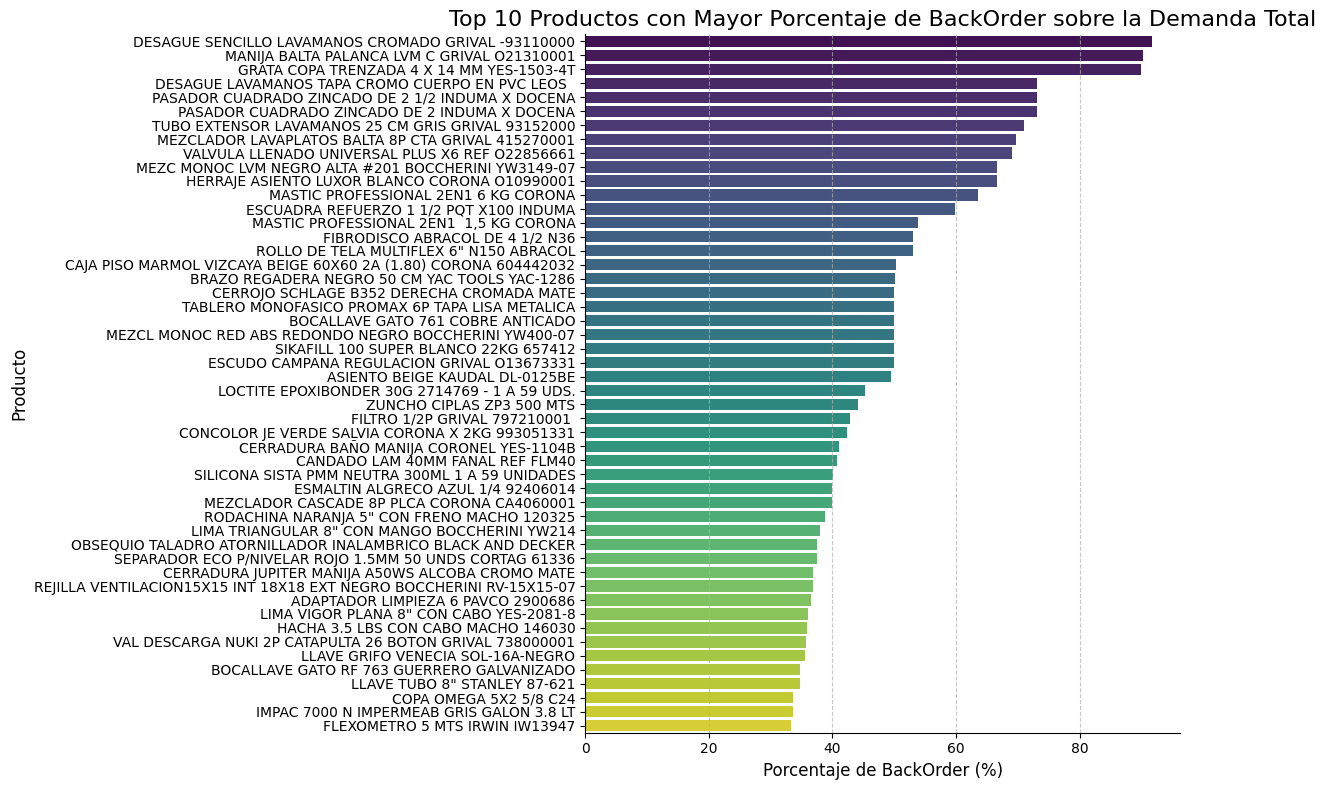

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# Recalcular BackOrderValue para asegurar que esté actualizado en el DataFrame principal
df['BackOrderValue'] = df['BackOrder'] * df['VlrUnitario']

# Recalcular VentaReal (lo que se facturó) para asegurar que esté actualizado
df['VentaReal'] = df['Facturado'] * df['VlrUnitario']

# Agrupar por producto y calcular el total de BackOrderValue y VentaReal
df_productos_summary = df.groupby('Producto').agg(
    Total_BackOrder_Value=('BackOrderValue', 'sum'),
    Total_Venta_Real=('VentaReal', 'sum')
).reset_index()

# Calcular la Demanda Total (Venta Real + BackOrder)
df_productos_summary['Demanda_Total'] = df_productos_summary['Total_BackOrder_Value'] + df_productos_summary['Total_Venta_Real']

# Calcular el porcentaje de BackOrder sobre la Demanda Total
df_productos_summary['Porcentaje_BackOrder'] = (df_productos_summary['Total_BackOrder_Value'] / df_productos_summary['Demanda_Total']) * 100

# Eliminar productos sin BackOrder o con demanda total cero para evitar divisiones por cero o ruido
df_productos_summary = df_productos_summary[
    (df_productos_summary['Porcentaje_BackOrder'].notna()) &
    (df_productos_summary['Porcentaje_BackOrder'] > 0)
]

# Ordenar por porcentaje de BackOrder de forma descendente y seleccionar los top 10
top_productos_backorder_pct = df_productos_summary.sort_values(
    by='Porcentaje_BackOrder', ascending=False
).head(50)

# Visualización
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Porcentaje_BackOrder',
    y='Producto',
    data=top_productos_backorder_pct,
    palette='viridis',
    hue='Producto', # Add hue to address FutureWarning
    legend=False # Disable legend if hue is used for categorical y-axis
)

plt.title('Top 10 Productos con Mayor Porcentaje de BackOrder sobre la Demanda Total', fontsize=16)
plt.xlabel('Porcentaje de BackOrder (%)', fontsize=12)
plt.ylabel('Producto', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
sns.despine()
plt.tight_layout()
plt.show()

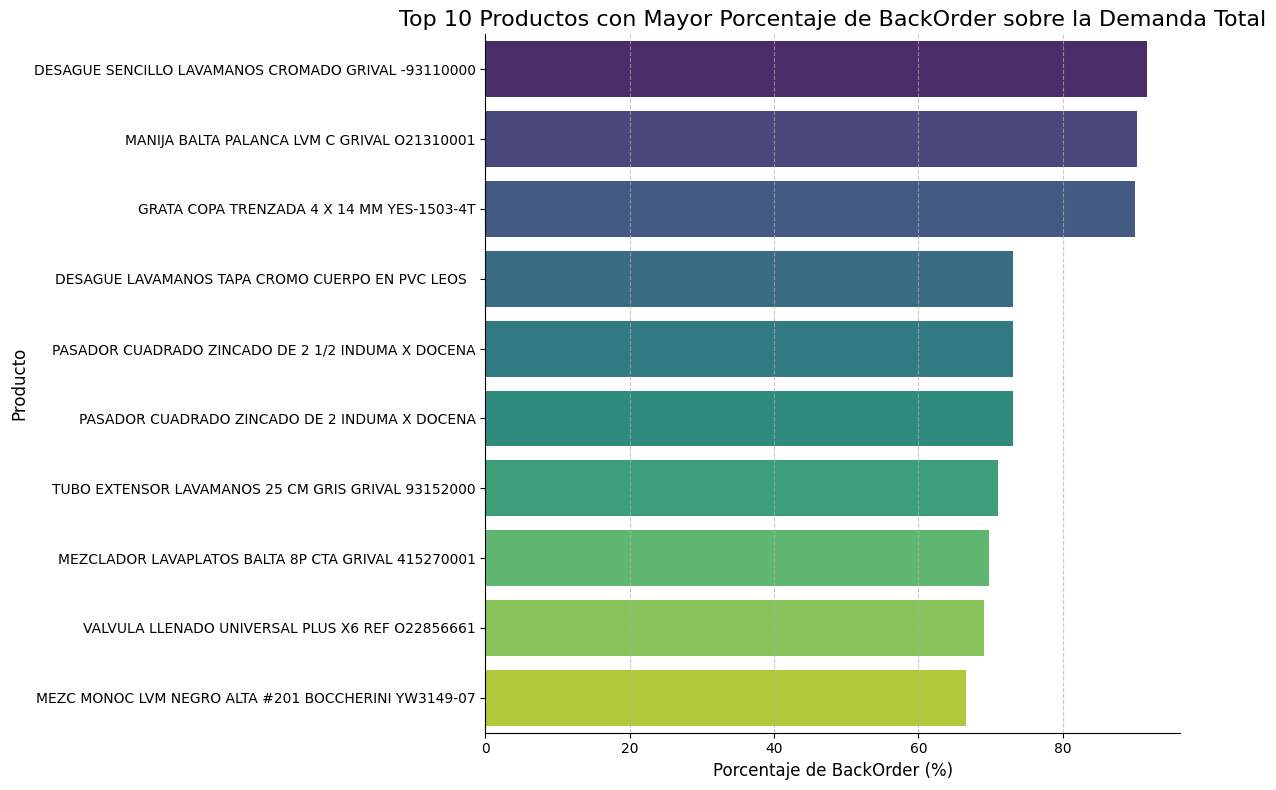

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurarse de que top_productos_backorder_pct está disponible
# Si no lo está, ejecutar la celda anterior que lo calcula
if 'top_productos_backorder_pct' in locals():
    plt.figure(figsize=(12, 8))
    sns.barplot(
        x='Porcentaje_BackOrder',
        y='Producto',
        data=top_productos_backorder_pct.head(10), # Limitar a los top 10 para esta visualización
        palette='viridis',
        hue='Producto',
        legend=False
    )

    plt.title('Top 10 Productos con Mayor Porcentaje de BackOrder sobre la Demanda Total', fontsize=16)
    plt.xlabel('Porcentaje de BackOrder (%)', fontsize=12)
    plt.ylabel('Producto', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'top_productos_backorder_pct' no está definido. Por favor, asegúrate de ejecutar la celda anterior.")

### **Tendencia Semanal de BackOrder vs. Demanda (Cantidad)**

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure df_ts is available (it should be from previous cells)
# Ensure top_productos_backorder_pct is available (it should be from previous cells)

# Create a directory to save the plots if it doesn't exist
output_dir = 'backorder_demand_plots'
os.makedirs(output_dir, exist_ok=True)

# Get the top 10 product names with the highest backorder percentage
top_10_productos_backorder_names = top_productos_backorder_pct['Producto'].head(10).tolist()

if not top_10_productos_backorder_names:
    print("No se encontraron productos con backorder para analizar.")
else:
    print(f"Generating and saving {len(top_10_productos_backorder_names)} plots to '{output_dir}/' directory.")
    for product_name in top_10_productos_backorder_names:
        # Filter df_ts for the current product
        df_product = df_ts[df_ts['Producto'] == product_name].copy()

        if df_product.empty:
            print(f"No hay datos para el producto: {product_name}")
            continue

        # Group by week and sum the 'Facturado' and 'BackOrder' quantities for the specific product
        df_weekly_product_demand_backorder = df_product.resample('W').agg({
            'Facturado': 'sum',
            'BackOrder': 'sum'
        }).fillna(0)

        # Create the plot for the current product
        plt.figure(figsize=(15, 7))
        sns.lineplot(x=df_weekly_product_demand_backorder.index, y=df_weekly_product_demand_backorder['Facturado'], label='Demanda (Cantidad Facturada)', marker='o', color='blue', alpha=0.7)
        sns.lineplot(x=df_weekly_product_demand_backorder.index, y=df_weekly_product_demand_backorder['BackOrder'], label='BackOrder (Cantidad Pendiente)', marker='x', color='red', alpha=0.7)

        plt.title(f'Tendencia Semanal de BackOrder vs. Demanda para: {product_name}', fontsize=16)
        plt.xlabel('Fecha', fontsize=12)
        plt.ylabel('Cantidad', fontsize=12)
        plt.legend(fontsize=10)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.xticks(rotation=45)
        plt.tight_layout()

        # Save the plot
        # Sanitize product_name for filename
        safe_product_name = "".join([c if c.isalnum() else "_" for c in product_name])[:50] # Limit length and sanitize
        file_path = os.path.join(output_dir, f'tendencia_semanal_{safe_product_name}.png')
        plt.savefig(file_path)
        plt.close() # Close the figure to free up memory and prevent it from being displayed inline

    print(f"All plots have been saved to the '{output_dir}/' directory.")

Generating and saving 10 plots to 'backorder_demand_plots/' directory.
All plots have been saved to the 'backorder_demand_plots/' directory.


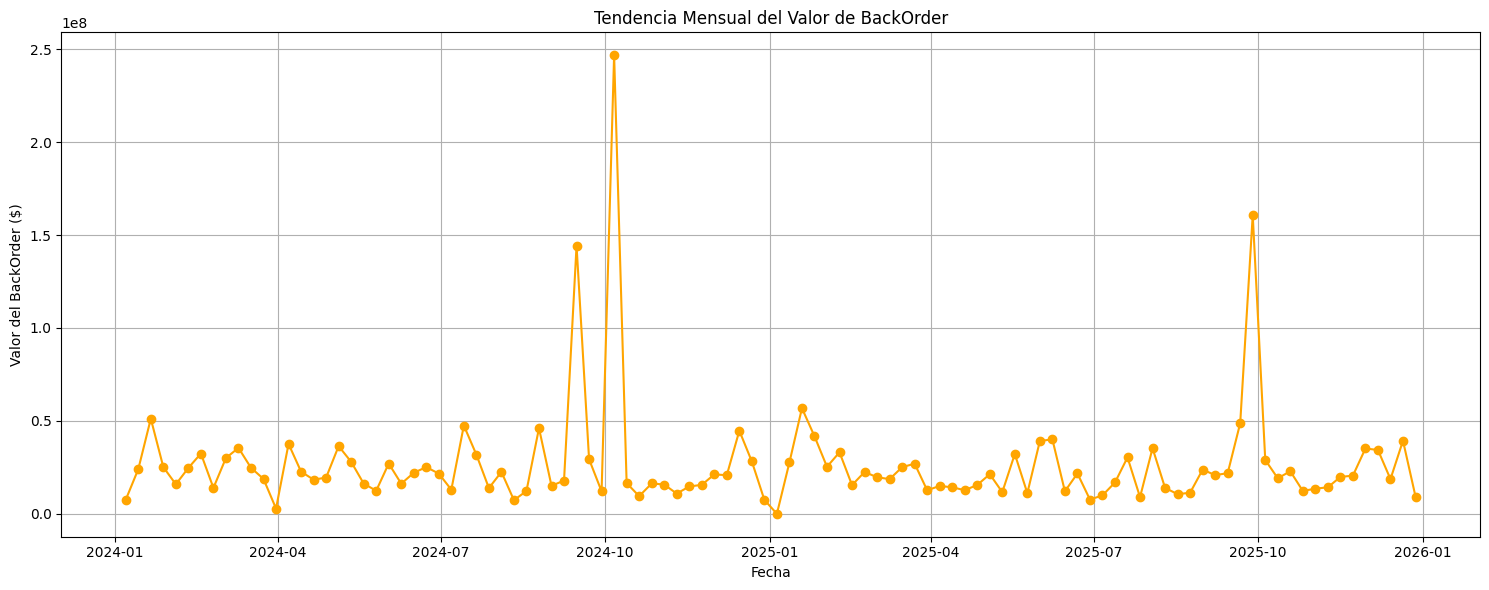

In [98]:
df_monthly_backorder = df_ts.resample('W')['BackOrderValue'].sum().fillna(0)

plt.figure(figsize=(15, 6))
plt.plot(df_monthly_backorder.index, df_monthly_backorder.values, marker='o', linestyle='-', color='orange')
plt.title('Tendencia Semanal del Valor de BackOrder')
plt.xlabel('Fecha')
plt.ylabel('Valor del BackOrder ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the specific product name to analyze
product_name_to_analyze = 'siliciona trasnarente henkel'

# Filter the main DataFrame (df_ts is already prepared for time series)
df_product_specific = df_ts[df_ts['Producto'].str.contains(product_name_to_analyze, case=False, na=False)].copy()

if df_product_specific.empty:
    print(f"No se encontraron ventas para el producto: '{product_name_to_analyze}'.")
else:
    # Group by week and sum the 'Facturado' and 'BackOrder' quantities for the specific product
    df_weekly_product_data = df_product_specific.resample('W').agg({
        'Facturado': 'sum',
        'BackOrder': 'sum'
    }).fillna(0)

    # Create the plot for the current product
    plt.figure(figsize=(15, 7))
    sns.lineplot(x=df_weekly_product_data.index, y=df_weekly_product_data['Facturado'], label='Demanda (Cantidad Facturada)', marker='o', color='blue', alpha=0.7)
    sns.lineplot(x=df_weekly_product_data.index, y=df_weekly_product_data['BackOrder'], label='BackOrder (Cantidad Pendiente)', marker='x', color='red', alpha=0.7)

    plt.title(f'Tendencia Semanal de BackOrder vs. Demanda para: {product_name_to_analyze}', fontsize=16)
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel('Cantidad', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

No se encontraron ventas para el producto: 'siliciona trasnarente henkel'.


In [54]:
# ==========================================================
# PORCENTAJE DE DEMANDA NO ATENDIDA (BACKORDER)
# ==========================================================

# 1. Asegurar variables numéricas
for col in ['VlrUnitario', 'Facturado', 'BackOrder']:
    if not pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

# 2. Calcular valores monetarios
df['VentaReal'] = df['Facturado'] * df['VlrUnitario']
df['BackOrderValue'] = df['BackOrder'] * df['VlrUnitario']

# 3. Totales
venta_real_total = df['VentaReal'].sum()
backorder_total = df['BackOrderValue'].sum()

# 4. Demanda total (lo que se quiso vender)
demanda_total = venta_real_total + backorder_total

# 5. Porcentaje de backorder
porcentaje_backorder = (backorder_total / demanda_total) * 100 if demanda_total != 0 else 0

# 6. Mostrar resultados
print("\n" + "="*80)
print("ANÁLISIS DE DEMANDA NO ATENDIDA (BACKORDER)")
print("="*80)
print(f"Venta real total: ${venta_real_total:,.2f}")
print(f"BackOrder total: ${backorder_total:,.2f}")
print(f"Demanda total: ${demanda_total:,.2f}")
print(f"\nPorcentaje de BackOrder: {porcentaje_backorder:.2f}%")


ANÁLISIS DE DEMANDA NO ATENDIDA (BACKORDER)
Venta real total: $243,092,883,316.77
BackOrder total: $2,772,292,750.10
Demanda total: $245,865,176,066.87

Porcentaje de BackOrder: 1.13%


In [56]:
# Análisis de BackOrder = 0
total_registros = len(df)
cantidad_backorder_cero = (df['BackOrder'] == 0).sum()
porcentaje_backorder_cero = (cantidad_backorder_cero / total_registros) * 100

#Mostrar resultados
print("\n" + "="*80)
print("RESGISTROS CON BACKORDER = 0")
print("="*80)
print(f"Total de registros: {total_registros:,}")
print(f"BackOrder igual a cero: {cantidad_backorder_cero:,}")
print(f"Porcentaje: {porcentaje_backorder_cero:.2f}%")


RESGISTROS CON BACKORDER = 0
Total de registros: 3,312,187
BackOrder igual a cero: 3,295,907
Porcentaje: 99.51%


#### Importante

Validar con el equipo si efectivamente se pudo suplir el 99% de la demanda en los 2 últimos años. En caso de que NO, ayudarnos con la limpieza y corrección del backorder

### ClaseVenta y Cantidad/Producto Obsequio

In [57]:
analizar_valores_unicos(df, 'ClaseVenta')


 VALORES ÚNICOS - CLASEVENTA
Cantidad de valores únicos: 2

Primeros 2 valores:
['NORMAL', 'FERIA-EVENTO']
Categories (2, object): ['FERIA-EVENTO', 'NORMAL']


In [58]:
# ==========================================================
# IDENTIFICACIÓN DE INTERVALOS DE FERIA / EVENTO
# ==========================================================

ventas_feria_evento = df[df['ClaseVenta'] == 'FERIA-EVENTO'].copy()

if ventas_feria_evento.empty:
    print("No se encontraron ventas de tipo 'FERIA-EVENTO' en el dataset.")
else:
    # Asegurar formato de fecha
    ventas_feria_evento['FECHA'] = pd.to_datetime(ventas_feria_evento['FECHA'], errors='coerce')

    # Ordenar por fecha
    ventas_feria_evento = ventas_feria_evento.sort_values('FECHA')

    # Eliminar duplicados de fecha (solo interesa la ocurrencia del día)
    fechas_unicas = ventas_feria_evento['FECHA'].drop_duplicates().sort_values()

    # Calcular diferencia entre días consecutivos
    diff_dias = fechas_unicas.diff().dt.days

    # Definir corte de evento (cuando hay más de 1 día de diferencia)
    evento_id = (diff_dias > 1).cumsum()

    # Crear DataFrame auxiliar
    df_eventos = pd.DataFrame({
        'FECHA': fechas_unicas,
        'evento_id': evento_id
    })

    # Agrupar por evento
    intervalos_eventos = df_eventos.groupby('evento_id')['FECHA'].agg(['min', 'max'])

    # Mostrar resultados
    print("\n" + "="*80)
    print("INTERVALOS DE FERIAS / EVENTOS DETECTADOS")
    print("="*80)

    for i, row in intervalos_eventos.iterrows():
        inicio = row['min'].strftime('%d-%m-%Y')
        fin = row['max'].strftime('%d-%m-%Y')
        duracion = (row['max'] - row['min']).days + 1

        print(f"Evento {i+1}: Inicio = {inicio} | Fin = {fin} | Duración = {duracion} días")


INTERVALOS DE FERIAS / EVENTOS DETECTADOS
Evento 1: Inicio = 27-05-2024 | Fin = 01-06-2024 | Duración = 6 días
Evento 2: Inicio = 04-06-2024 | Fin = 08-06-2024 | Duración = 5 días
Evento 3: Inicio = 11-06-2024 | Fin = 11-06-2024 | Duración = 1 días
Evento 4: Inicio = 14-06-2024 | Fin = 14-06-2024 | Duración = 1 días
Evento 5: Inicio = 17-06-2024 | Fin = 19-06-2024 | Duración = 3 días
Evento 6: Inicio = 26-06-2024 | Fin = 26-06-2024 | Duración = 1 días
Evento 7: Inicio = 29-06-2024 | Fin = 29-06-2024 | Duración = 1 días
Evento 8: Inicio = 05-09-2024 | Fin = 07-09-2024 | Duración = 3 días
Evento 9: Inicio = 09-09-2024 | Fin = 14-09-2024 | Duración = 6 días
Evento 10: Inicio = 16-09-2024 | Fin = 21-09-2024 | Duración = 6 días
Evento 11: Inicio = 23-09-2024 | Fin = 28-09-2024 | Duración = 6 días
Evento 12: Inicio = 30-09-2024 | Fin = 01-10-2024 | Duración = 2 días
Evento 13: Inicio = 05-10-2024 | Fin = 05-10-2024 | Duración = 1 días
Evento 14: Inicio = 09-10-2024 | Fin = 09-10-2024 | Dura

In [59]:
# precio promedio en eventos vs normal
# revisar correlacion ( grafico y matriz)

In [60]:
analizar_nulos(df, 'ClaseVenta')


 VALORES NULOS - CLASEVENTA
Cantidad de valores nulos: 0
Porcentaje de nulos: 0.00%


/tmp/ipykernel_1863/186869646.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


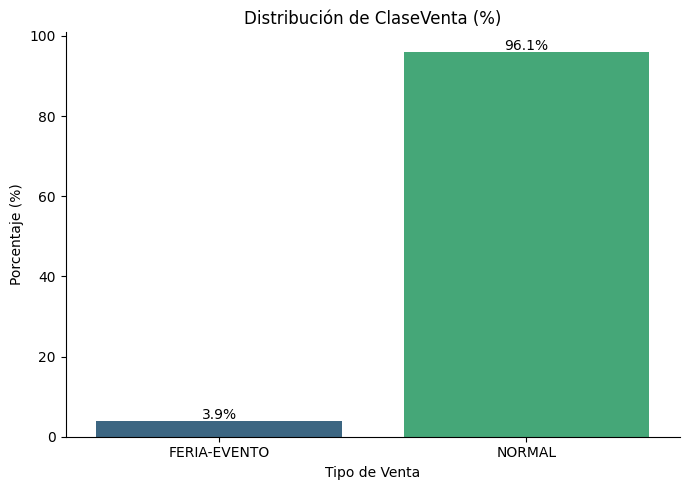

In [61]:
# Distribución de ClaseVenta (%)

# Calcular porcentajes
percentages = df['ClaseVenta'].value_counts(normalize=True) * 100

# Gráfico
plt.figure(figsize=(7, 5))
ax = sns.barplot(
    x=percentages.index,
    y=percentages.values,
    palette='viridis'
)

# Títulos
plt.title('Distribución de ClaseVenta (%)')
plt.xlabel('Tipo de Venta')
plt.ylabel('Porcentaje (%)')

# Etiquetas
for barra in ax.patches:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width()/2,
        altura + 0.5,
        f"{altura:.1f}%",
        ha='center'
    )

sns.despine()
plt.tight_layout()
plt.show()

**IMPORTANTE**

Validar si es correcta esta distribución de ventas regulares y feriadas

In [62]:
analizar_nulos(df, 'CantidadObsequio')


 VALORES NULOS - CANTIDADOBSEQUIO
Cantidad de valores nulos: 0
Porcentaje de nulos: 0.00%


In [63]:
# Análisis de CantidadObsequio = 0
total_registros = len(df)
cantidad_CantidadObsequio_cero = (df['CantidadObsequio'] == 0).sum()
porcentaje_CantidadObsequio_cero = (cantidad_CantidadObsequio_cero / total_registros) * 100

#Mostrar resultados
print("\n" + "="*80)
print("RESGISTROS CON CantidadObsequio = 0")
print("="*80)
print(f"Total de registros: {total_registros:,}")
print(f"CantidadObsequio igual a cero: {cantidad_CantidadObsequio_cero:,}")
print(f"Porcentaje: {porcentaje_CantidadObsequio_cero:.2f}%")


RESGISTROS CON CantidadObsequio = 0
Total de registros: 3,312,187
CantidadObsequio igual a cero: 3,312,124
Porcentaje: 100.00%


**IMPORTANTE**

Esta variable 'Cantidad/Producto Obsequio'podría no ser relevante en el análisis

In [64]:
# Guardar dataset limpio
output_path = '/content/drive/MyDrive/Trabajo de Grado JuanPablo/Dataset_cleaned.csv'
df_to_save = df.reset_index()
df_to_save.to_csv(output_path, index=False, sep=';')
print(f"Dataset limpio guardado en: {output_path}")

Dataset limpio guardado en: /content/drive/MyDrive/Trabajo de Grado JuanPablo/Dataset_cleaned.csv


### **Análisis Exploratorio**

La demanda se registra a nivel **diario**, lo que equivaldría a aproximadamente **730 periodos** para el análisis. Sin embargo, trabajar con esta granularidad presenta desafíos importantes, principalmente por la **alta volatilidad de la serie**, lo que dificulta la identificación de **patrones, tendencias y estacionalidades** de forma clara.

Por esta razón, se evaluaron diferentes niveles de agregación temporal:

### **1. Agregación mensual**
Permite suavizar significativamente la serie y reducir la variabilidad.

**Ventaja:**
- Mayor estabilidad en los datos  

**Desventaja:**
- Reducción considerable del número de observaciones (**24 periodos**)  
- Limitaciones para aplicar modelos que requieren mayor cantidad de datos históricos  

---

### **2. Agregación semanal**
Se plantea como una alternativa intermedia entre detalle y estabilidad.

**Ventajas:**
- Balance adecuado entre **granularidad y suavización de la serie**  
- Incremento en el número de observaciones frente al enfoque mensual  
- Mejora la capacidad para identificar patrones de comportamiento  

Adicionalmente, trabajar a nivel semanal resulta más consistente con la lógica operativa del negocio:

- Facilita la integración de modelos de **forecasting** con el cálculo de **stock de seguridad**  
- Permite generar pronósticos más realistas en horizontes de corto plazo  
- Se alinea mejor con los **lead times** de los proveedores, que generalmente se expresan en días o semanas  

---

## **Conclusión**

Se selecciona la **agregación semanal** como nivel de análisis, ya que ofrece un equilibrio adecuado entre estabilidad estadística y nivel de detalle, permitiendo desarrollar modelos más robustos y alineados con la dinámica real del negocio.

In [65]:
# Visualizar dataset limpio
df = pd.read_csv('/content/drive/MyDrive/Trabajo de Grado JuanPablo/Dataset_cleaned.csv', sep=';', on_bad_lines='skip', parse_dates=['FECHA'])
df.head(10)

/tmp/ipykernel_1863/104203983.py:2: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Trabajo de Grado JuanPablo/Dataset_cleaned.csv', sep=';', on_bad_lines='skip', parse_dates=['FECHA'])


,index,FECHA,Semana,Bodega,IDFactura,IDProducto,VlrUnitario,Producto,ClaseProducto,DiasImportacion,...,Departamento,Vendedor,Facturado,BackOrder,ClaseVenta,ProductoObsequio,CantidadObsequio,VentaTotal,BackOrderValue,VentaReal
0,0,2025-09-06,36,PALOQUEMAO,2071756,282,876.0,BUJE LAVAMANOS 1 1/2 CAUCHO PLASTGRIFOS,Griferias,NaN,...,META,CLAUDIA RODRIGUEZ,6,0,NORMAL,NaN,0,5256.0,0.0,5256.0
1,1,2024-11-07,45,PALOQUEMAO,1940864,1708,18950.0,TIJERA PODADORA BELLOTA 3501-18 7,Herramientas,15.0,...,CUNDINAMARCA,LEONARDO QUINTERO,2,0,NORMAL,NaN,0,37900.0,0.0,37900.0
2,2,2024-01-25,4,BODEGA CRA 16,1826114,8770,264060.0,ALAMBRE DE PUAS 12.5X350MTS CORSAN,Fijacion y Amarres,7.0,...,CUNDINAMARCA,KARINA RODRIGUEZ,1,0,NORMAL,NaN,0,264060.0,0.0,264060.0
3,3,2025-01-23,4,PALOQUEMAO,1971682,1364,1560.0,PVC SEMICODO 2 CXC LEO,Plomeria,8.0,...,BOGOTA D.C.,ALEXANDER JIMENEZ,4,0,NORMAL,NaN,0,6240.0,0.0,6240.0
4,4,2024-02-28,9,BODEGA CRA 16,1839937,5294,34700.0,CHEQUE CORTINA 1 GRIVAL 797170001,Plomeria,14.0,...,CUNDINAMARCA,KARINA RODRIGUEZ,3,0,NORMAL,NaN,0,104100.0,0.0,104100.0
5,5,2024-02-29,9,PALOQUEMAO,1840030,3405,13400.0,CERRADURA ALCOBA MADERA CORONEL OSCURA DL-1043C,Seguridad,165.0,...,CUNDINAMARCA,LEONARDO QUINTERO,3,0,NORMAL,NaN,0,40200.0,0.0,40200.0
6,6,2025-09-25,39,PALOQUEMAO,2080836,11702,24680.0,SIKAFLEX UNIVERSAL GRIS X 300ML\t - 515119,Construccion,15.0,...,BOGOTA D.C.,MILTON FLOREZ,1,0,NORMAL,NaN,0,24680.0,0.0,24680.0
7,7,2024-04-04,14,PALOQUEMAO,1852635,6317,280.0,ADAPTADOR ROSCADO HEMBRA DE 1/2 PAVCO 2900714,Plomeria,5.0,...,CUNDINAMARCA,ODUAR HARVEY CARDENAS RODRIGUEZ,100,0,NORMAL,NaN,0,28000.0,0.0,28000.0
8,8,2024-05-23,21,PALOQUEMAO,1872306,13269,60690.0,CINTA MULTISEAL 33 CM X 5MT TEXSA,Pinturas Y Adhesivos,8.0,...,CUNDINAMARCA,ALBERTO GUTIERREZ,3,0,NORMAL,NaN,0,182070.0,0.0,182070.0
9,9,2025-07-23,30,BODEGA CRA 16,2050744,8719,4300.0,SIFON ESCUALIZABLE KAUDAL DL-1231,Griferias,120.0,...,CUNDINAMARCA,KARINA RODRIGUEZ,10,0,NORMAL,NaN,0,43000.0,0.0,43000.0


In [66]:
# Construcción de serie de tiempo semanal
df_ts = df.copy()
df_ts['FECHA'] = pd.to_datetime(df_ts['FECHA'], errors='coerce')
df_ts = df_ts.dropna(subset=['FECHA'])

# Convertir a numérico
df_ts['VlrUnitario'] = df_ts['VlrUnitario'].astype(str).str.replace(',', '.', regex=False).astype(float)
df_ts['Facturado'] = df_ts['Facturado'].astype(str).str.replace(',', '.', regex=False).astype(float)

# Generar variable de valor total de la venta
df_ts['VentaTotal'] = df_ts['VlrUnitario'] * df_ts['Facturado']
df_ts = df_ts.set_index('FECHA').sort_index()

# Re-muestrear a frecuencia semanal
df_weekly = df_ts.resample('W').agg({
    'Facturado': 'sum',     # volumen total semanal (demanda)
    'VentaTotal': 'sum',    # valor total semanal ($)
    'VlrUnitario': 'mean'   # precio promedio semanal
})
df_weekly = df_weekly.fillna(0)

# Ver serie
print(df_weekly.head(10))

            Facturado    VentaTotal   VlrUnitario
FECHA                                            
2024-01-07   151833.0  7.304624e+08  12757.728269
2024-01-14   407966.0  1.930676e+09  13918.034565
2024-01-21   609221.0  2.635401e+09  14225.613882
2024-01-28   474115.0  2.341858e+09  18582.820696
2024-02-04   484368.0  2.137127e+09  14357.547569
2024-02-11   374383.0  1.905384e+09  15488.077423
2024-02-18   476396.0  2.268628e+09  16525.489114
2024-02-25   428504.0  2.155232e+09  15574.484012
2024-03-03   470012.0  2.051402e+09  14267.026870
2024-03-10   529222.0  2.438204e+09  15176.749832


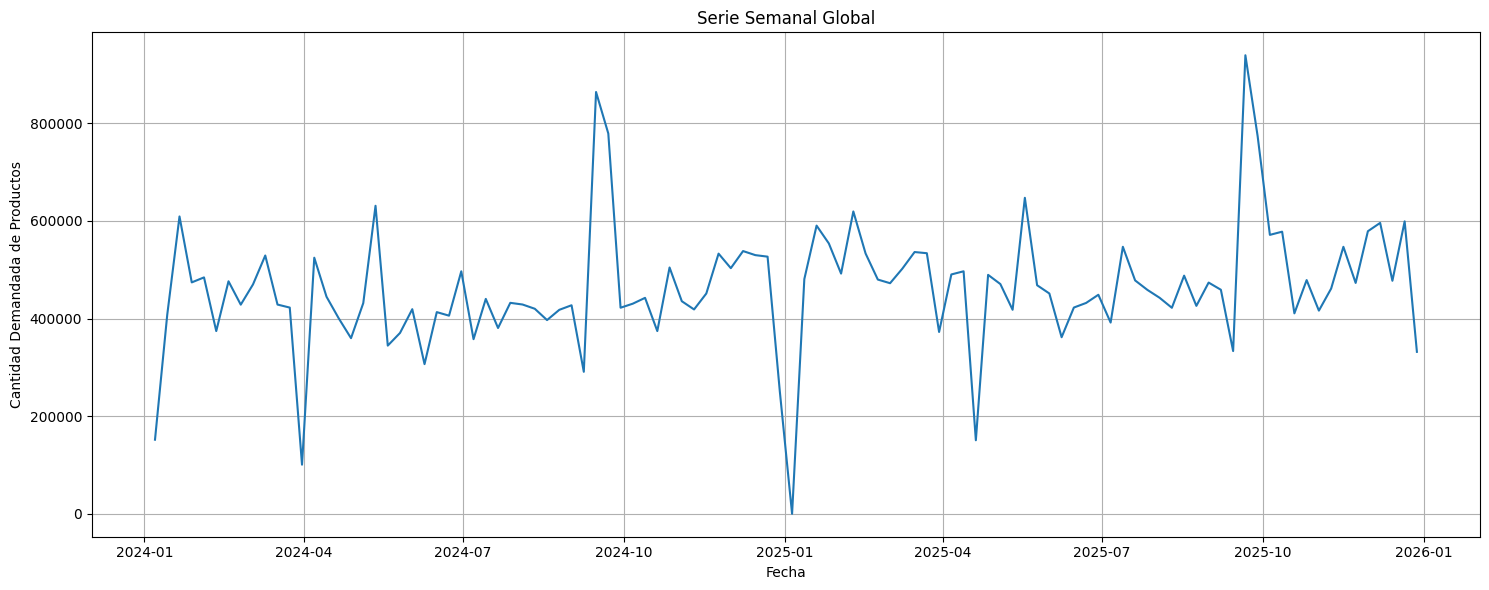

In [67]:
# Serie General de Demanda
fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(df_weekly.index, df_weekly['Facturado'])
ax1.set_ylabel('Cantidad Demandada de Productos')
ax1.set_xlabel('Fecha')

plt.title('Serie Semanal Global')
plt.grid(True)
plt.tight_layout()
plt.show()

A continuación se presentan los rangos de semanas con anormalidades (picos y valles) detectados en la demanda de ventas normales:

--- Año 2024 ---
  Semana 3: Peak
  Semana 4: Valley
  Semana 5: Peak
  Semana 6: Valley
  Semana 7: Peak
  Semana 8: Valley
  Semana 10: Peak
  Semana 13: Valley
  Semana 14: Peak
  Semana 17: Valley
  Semana 19: Peak
  Semana 20: Valley
  Semana 21: Peak
  Semana 22: Valley
  Semana 24: Peak
  Semana 25: Valley
  Semana 26: Peak
  Semana 27: Valley
  Semana 28: Peak
  Semana 29: Valley
  Semana 30: Peak
  Semana 33: Valley
  Semana 35: Peak
  Semana 36: Valley
  Semana 38: Peak
  Semana 39: Valley
  Semana 41: Peak
  Semana 42: Valley
  Semana 43: Peak
  Semana 45: Valley
  Semana 47: Peak
  Semana 48: Valley
  Semana 49: Peak


--- Año 2025 ---
  Semana 1: Valley
  Semana 3: Peak
  Semana 5: Valley
  Semana 6: Peak
  Semana 9: Valley
  Semana 11: Peak
  Semana 13: Valley
  Semana 15: Peak
  Semana 16: Valley
  Semana 17: Peak
  Semana 20: Valley
  Semana

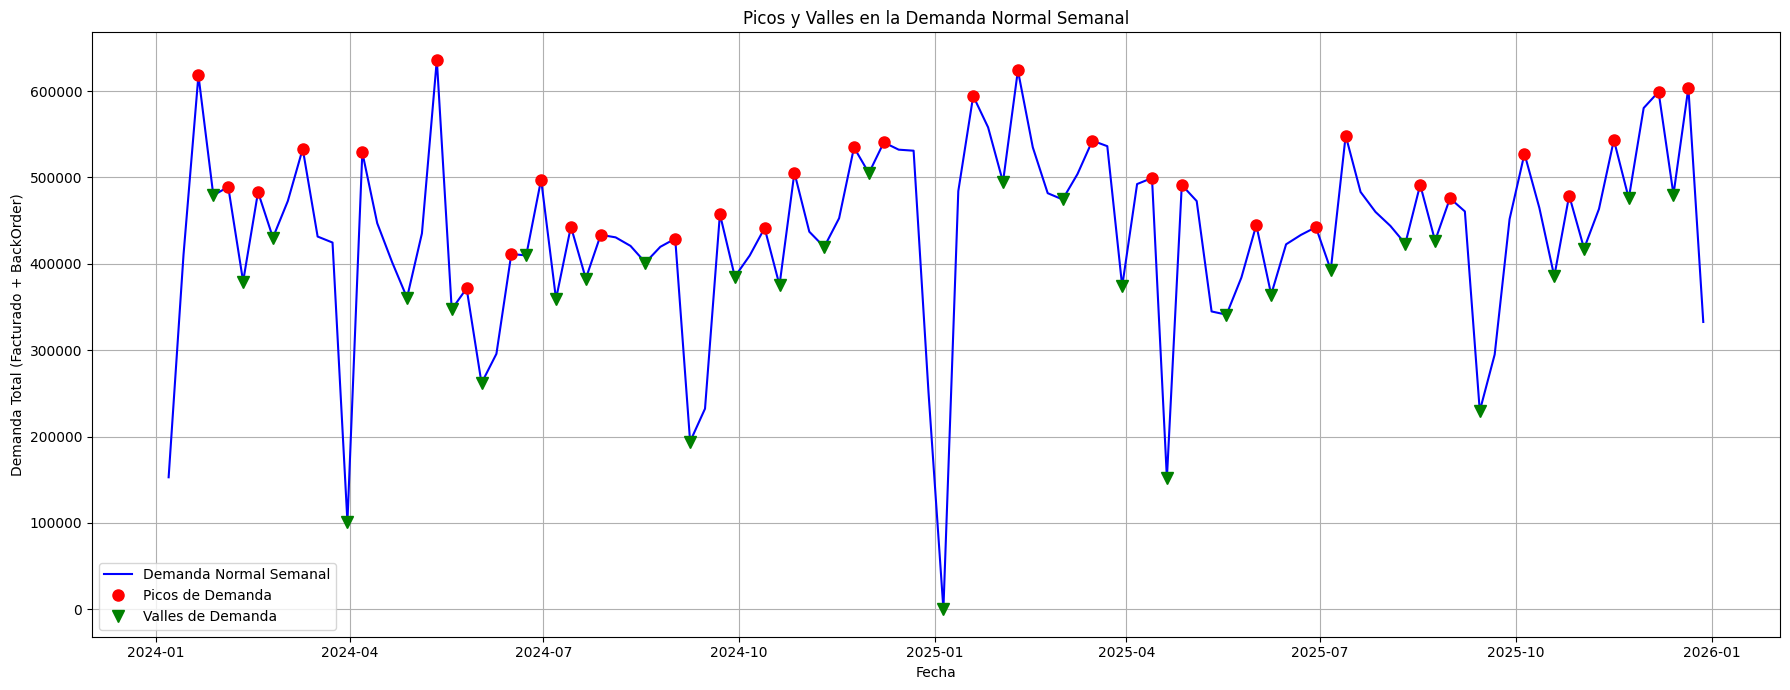

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Filter df for 'NORMAL' sales
df_normal_sales = df[df['ClaseVenta'] == 'NORMAL'].copy()

# Ensure 'FECHA' is datetime
df_normal_sales['FECHA'] = pd.to_datetime(df_normal_sales['FECHA'])

# Use the existing 'Venta_Calculada' column
# If 'Venta_Calculada' doesn't exist, calculate it first.
if 'Venta_Calculada' not in df_normal_sales.columns:
    df_normal_sales['Venta_Calculada'] = df_normal_sales['Facturado'] + df_normal_sales['BackOrder']

# Set 'FECHA' as index and aggregate weekly
df_weekly_normal_ts = df_normal_sales.set_index('FECHA').resample('W')['Venta_Calculada'].sum().fillna(0)

# Create a DataFrame with Week, Year, and adjusted Semana_del_Año
df_weekly_normal_indexed = df_weekly_normal_ts.reset_index()
df_weekly_normal_indexed['Year'] = df_weekly_normal_indexed['FECHA'].dt.year
df_weekly_normal_indexed['Semana_del_Año'] = df_weekly_normal_indexed['FECHA'].dt.isocalendar().week.astype(int)

# Adjust week 53 to week 52 for years that have it, as per user request "cuenta 52 por año"
df_weekly_normal_indexed.loc[df_weekly_normal_indexed['Semana_del_Año'] == 53, 'Semana_del_Año'] = 52

# 2. Identify peaks and valleys using a simple method (local extrema)
# A peak is when current > previous AND current > next
# A valley is when current < previous AND current < next

# Use the aggregated weekly data for peak/valley detection
demand_series = df_weekly_normal_indexed['Venta_Calculada']

demand_prev = demand_series.shift(1)
demand_next = demand_series.shift(-1)

# Identify peaks and valleys by their index in the df_weekly_normal_indexed DataFrame
peaks_indices = df_weekly_normal_indexed.index[
    (demand_series > demand_prev) &
    (demand_series > demand_next)
]
valleys_indices = df_weekly_normal_indexed.index[
    (demand_series < demand_prev) &
    (demand_series < demand_next)
]

# Create a DataFrame to hold all weeks and their status for anomaly detection
df_anomalies_status = df_weekly_normal_indexed[['FECHA', 'Year', 'Semana_del_Año']].copy()
df_anomalies_status['Status'] = 'Normal'

# Mark peaks and valleys
df_anomalies_status.loc[peaks_indices, 'Status'] = 'Peak'
df_anomalies_status.loc[valleys_indices, 'Status'] = 'Valley'

# 3. Identify and print ranges of anomalies for each year
print("A continuación se presentan los rangos de semanas con anormalidades (picos y valles) detectados en la demanda de ventas normales:\n")

for year in sorted(df_anomalies_status['Year'].unique()):
    print(f"--- Año {year} ---")
    df_year_anomalies = df_anomalies_status[df_anomalies_status['Year'] == year].sort_values('Semana_del_Año')

    current_range_start_week = None
    current_range_type = None
    anomalous_ranges = []

    for index, row in df_year_anomalies.iterrows():
        week = row['Semana_del_Año']
        status = row['Status']

        if status != 'Normal':
            if current_range_type is None: # Start a new range
                current_range_start_week = week
                current_range_type = status
            elif status != current_range_type: # Type changed, end previous range and start new
                anomalous_ranges.append((current_range_start_week, week - 1, current_range_type))
                current_range_start_week = week
                current_range_type = status
            # If status is the same, continue the current range
        else: # Status is Normal
            if current_range_type is not None: # End the current range
                anomalous_ranges.append((current_range_start_week, week - 1, current_range_type))
                current_range_start_week = None
                current_range_type = None

    # After loop, if a range is still open, add it (handle last range of the year)
    if current_range_type is not None:
        anomalous_ranges.append((current_range_start_week, df_year_anomalies['Semana_del_Año'].max(), current_range_type))

    if not anomalous_ranges:
        print("  No se detectaron rangos de anormalidades.")
    else:
        for start_week, end_week, anomaly_type in anomalous_ranges:
            # Ensure end_week is not less than start_week, especially for single-week anomalies
            if end_week < start_week:
                end_week = start_week

            if start_week == end_week:
                print(f"  Semana {start_week}: {anomaly_type}")
            else:
                print(f"  Semanas {start_week}-{end_week}: {anomaly_type}")
    print("\n")


# 4. Visualize the results
plt.figure(figsize=(18, 7))
plt.plot(df_weekly_normal_indexed['FECHA'], df_weekly_normal_indexed['Venta_Calculada'], label='Demanda Normal Semanal', color='blue')

# Mark peaks
if not peaks_indices.empty:
    plt.plot(df_weekly_normal_indexed.loc[peaks_indices, 'FECHA'], df_weekly_normal_indexed.loc[peaks_indices, 'Venta_Calculada'], 'o', color='red', markersize=8, label='Picos de Demanda')

# Mark valleys
if not valleys_indices.empty:
    plt.plot(df_weekly_normal_indexed.loc[valleys_indices, 'FECHA'], df_weekly_normal_indexed.loc[valleys_indices, 'Venta_Calculada'], 'v', color='green', markersize=8, label='Valles de Demanda')

plt.title('Picos y Valles en la Demanda Normal Semanal')
plt.xlabel('Fecha')
plt.ylabel('Demanda Total (Facturado + BackOrder)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

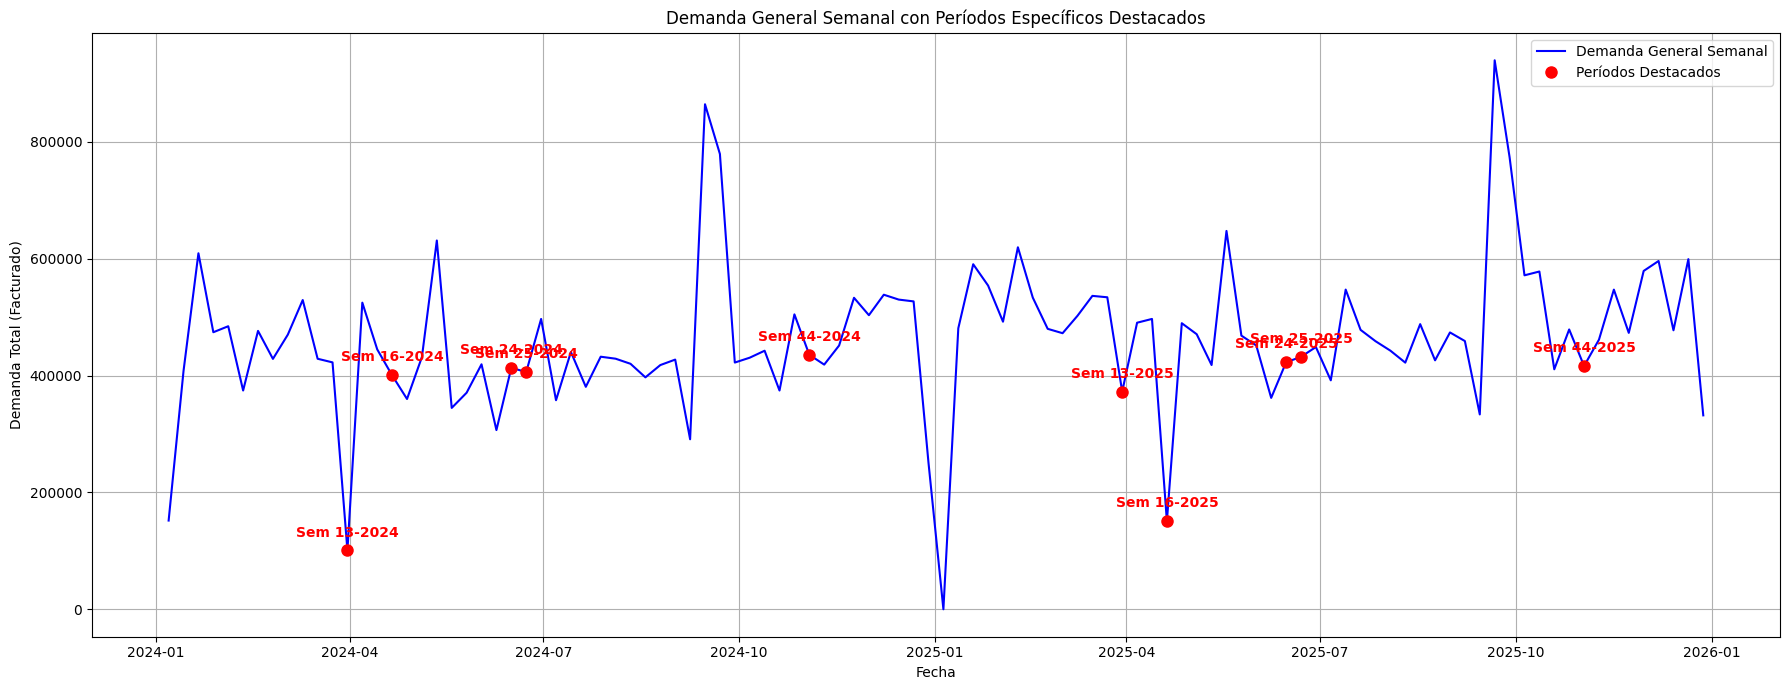

In [69]:
import matplotlib.pyplot as plt
import pandas as pd

# Recreate df_weekly with Year and Semana_del_Año for accurate plotting
df_weekly_plot = df_weekly.copy()
df_weekly_plot['Year'] = df_weekly_plot.index.year
df_weekly_plot['Semana_del_Año'] = df_weekly_plot.index.isocalendar().week.astype(int)

# Adjust week 53 to week 52 for years that have it
df_weekly_plot.loc[df_weekly_plot['Semana_del_Año'] == 53, 'Semana_del_Año'] = 52

# Define the specific points to highlight based on user's request (Week, Year)
highlight_points = [
        (13, 2024),
        (24, 2024),
        (16, 2024),
        (25, 2024),
        (44, 2024),
        (13, 2025),
        (24, 2025),
        (16, 2025),
        (25, 2025),
        (44, 2025)
    ]
# Find the actual dates for these highlight points for plotting
highlight_dates = []
for week, year in highlight_points:
    # Find the entry in df_weekly_plot that matches the week and year
    matching_row = df_weekly_plot[
        (df_weekly_plot['Year'] == year) &
        (df_weekly_plot['Semana_del_Año'] == week)
    ]
    if not matching_row.empty:
        # Get the date (index) of the first matching row
        highlight_dates.append(matching_row.index[0])

# Plot the general demand
plt.figure(figsize=(18, 7))
plt.plot(df_weekly_plot.index, df_weekly_plot['Facturado'], label='Demanda General Semanal', color='blue')

# Mark the specific highlight points
if highlight_dates:
    highlight_values = df_weekly_plot.loc[highlight_dates, 'Facturado']
    plt.plot(highlight_dates, highlight_values, 'o', color='red', markersize=8, label='Períodos Destacados')
    # Add text annotations for each highlighted point
    for date, value in zip(highlight_dates, highlight_values):
        week = df_weekly_plot.loc[date, 'Semana_del_Año']
        year = df_weekly_plot.loc[date, 'Year']
        plt.annotate(f'Sem {week}-{year}', (date, value), textcoords="offset points", xytext=(0,10), ha='center', color='red', weight='bold')

plt.title('Demanda General Semanal con Períodos Específicos Destacados')
plt.xlabel('Fecha')
plt.ylabel('Demanda Total (Facturado)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

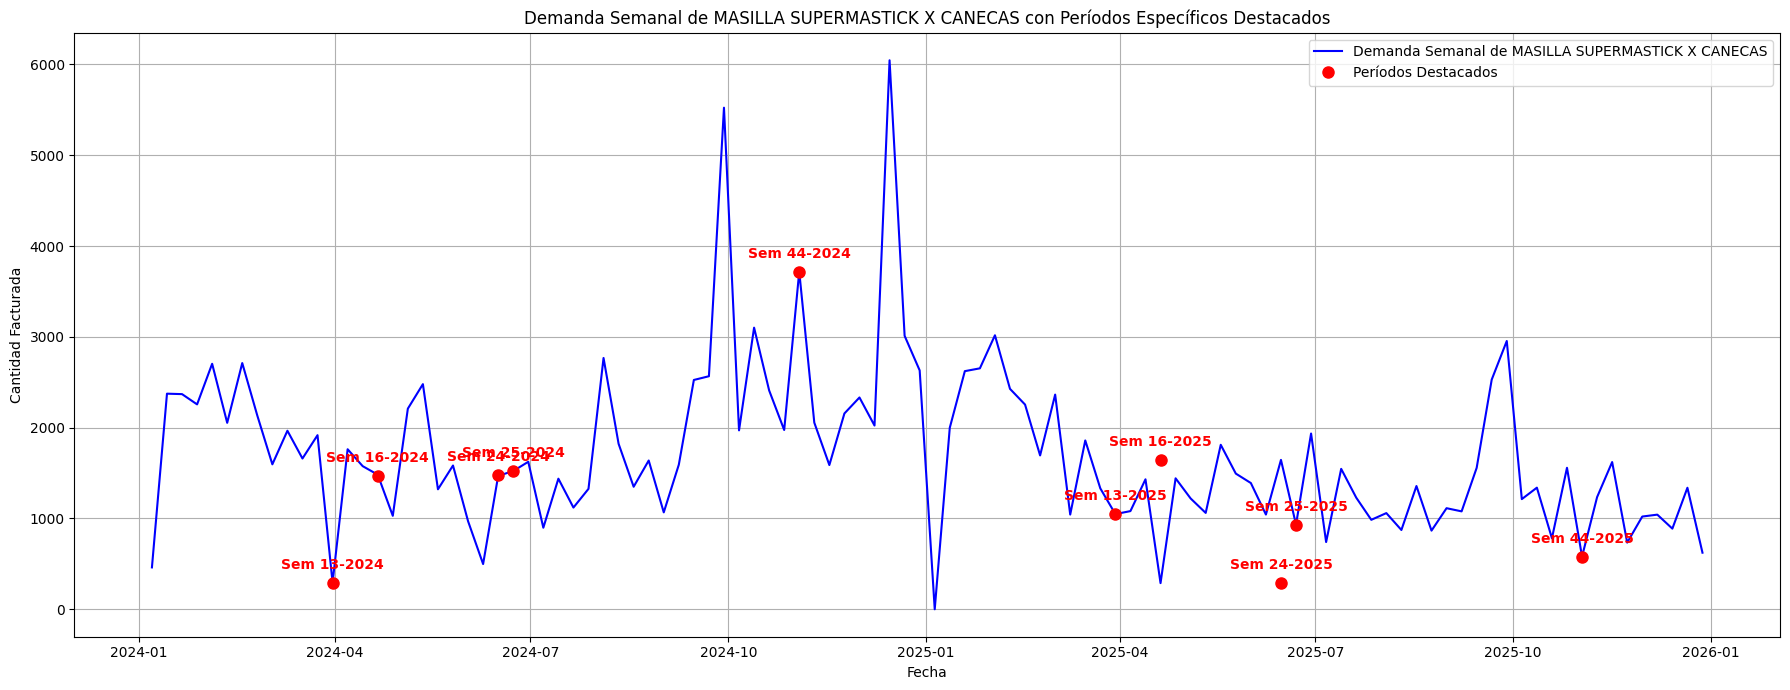

In [70]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the specific product name to analyze
product_name_to_analyze = 'MASILLA SUPERMASTICK X CANECAS'

# Filter the main DataFrame for this specific product
df_product = df[df['Producto'] == product_name_to_analyze].copy()

if df_product.empty:
    print(f"No se encontraron ventas para el producto: '{product_name_to_analyze}'.")
else:
    # Ensure 'FECHA' is datetime
    df_product['FECHA'] = pd.to_datetime(df_product['FECHA'])

    # Calculate total demand (Facturado) and resample to weekly
    df_product_weekly = df_product.set_index('FECHA').resample('W')['Facturado'].sum().reset_index()

    # Add Year and Semana_del_Año columns for consistency with previous plots
    df_product_weekly['Year'] = df_product_weekly['FECHA'].dt.year
    df_product_weekly['Semana_del_Año'] = df_product_weekly['FECHA'].dt.isocalendar().week.astype(int)

    # Adjust week 53 to week 52 for years that have it
    df_product_weekly.loc[df_product_weekly['Semana_del_Año'] == 53, 'Semana_del_Año'] = 52

    # Define the specific points to highlight based on user's previous request (Week, Year)
    highlight_points = [
        (13, 2024),
        (24, 2024),
        (16, 2024),
        (25, 2024),
        (44, 2024),
        (13, 2025),
        (24, 2025),
        (16, 2025),
        (25, 2025),
        (44, 2025)
    ]

    # Find the actual dates for these highlight points for plotting
    highlight_dates = []
    for week, year in highlight_points:
        # Find the entry in df_product_weekly that matches the week and year
        matching_row = df_product_weekly[
            (df_product_weekly['Year'] == year) &
            (df_product_weekly['Semana_del_Año'] == week)
        ]
        if not matching_row.empty:
            # Get the date (FECHA) of the first matching row
            highlight_dates.append(matching_row['FECHA'].iloc[0])

    # Plot the product's demand
    plt.figure(figsize=(18, 7))
    plt.plot(df_product_weekly['FECHA'], df_product_weekly['Facturado'], label=f'Demanda Semanal de {product_name_to_analyze}', color='blue')

    # Mark the specific highlight points
    if highlight_dates:
        # Ensure highlight_dates are sorted to align with df_product_weekly index if needed
        highlight_values = df_product_weekly[df_product_weekly['FECHA'].isin(highlight_dates)]['Facturado']
        plt.plot(highlight_dates, highlight_values, 'o', color='red', markersize=8, label='Períodos Destacados')
        # Add text annotations for each highlighted point
        for date_val, value in zip(highlight_dates, highlight_values):
            # Find the week and year corresponding to the date_val
            row_info = df_product_weekly[df_product_weekly['FECHA'] == date_val].iloc[0]
            week = row_info['Semana_del_Año']
            year = row_info['Year']
            plt.annotate(f'Sem {week}-{year}', (date_val, value), textcoords="offset points", xytext=(0,10), ha='center', color='red', weight='bold')

    plt.title(f'Demanda Semanal de {product_name_to_analyze} con Períodos Específicos Destacados')
    plt.xlabel('Fecha')
    plt.ylabel('Cantidad Facturada')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

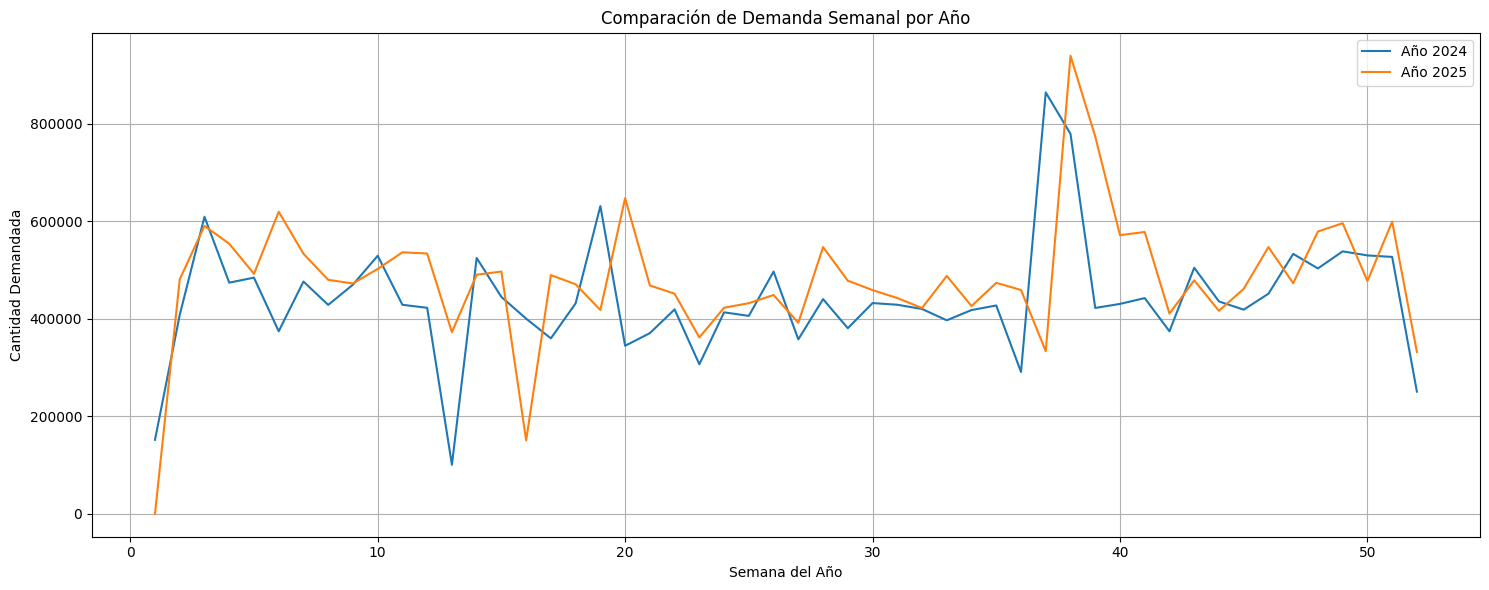

In [71]:
# ==========================================================
# SERIE SEMANAL POR AÑO (SUPERPUESTA)
# ==========================================================

# Crear copia
df_plot = df_weekly.copy()

# Extraer año y semana del índice
df_plot['Año'] = df_plot.index.year
df_plot['Semana'] = df_plot.index.isocalendar().week

# Crear gráfico
plt.figure(figsize=(15, 6))

# Graficar cada año como una línea
for año in df_plot['Año'].unique():
    datos_año = df_plot[df_plot['Año'] == año]

    plt.plot(
        datos_año['Semana'],
        datos_año['Facturado'],
        label=f'Año {año}'
    )

# Etiquetas
plt.xlabel('Semana del Año')
plt.ylabel('Cantidad Demandada')
plt.title('Comparación de Demanda Semanal por Año')

# Leyenda
plt.legend()

# Estética
plt.grid(True)
plt.tight_layout()
plt.show()

In [72]:
# Encontrar la fecha de menor demanda para cada año

# Asegurarse de que el índice sea de tipo datetime
if not isinstance(df_weekly.index, pd.DatetimeIndex):
    df_weekly.index = pd.to_datetime(df_weekly.index)

print("\n" + "="*60)
print("FECHA DE MENOR DEMANDA POR AÑO")
print("="*60)

# Agrupar por año y encontrar la fila con el menor 'Facturado' para cada año
lowest_demand_dates = df_weekly.loc[df_weekly.groupby(df_weekly.index.year)['Facturado'].idxmin()]

for year, row in lowest_demand_dates.iterrows():
    date_of_min_demand = year.strftime('%Y-%m-%d') # 'year' here is the index (DatetimeIndex)
    min_demand = row['Facturado']
    print(f"Año: {year.year} | Fecha con menor demanda: {date_of_min_demand} | Demanda: {min_demand:,.0f}")


FECHA DE MENOR DEMANDA POR AÑO
Año: 2024 | Fecha con menor demanda: 2024-03-31 | Demanda: 100,652
Año: 2025 | Fecha con menor demanda: 2025-01-05 | Demanda: 20


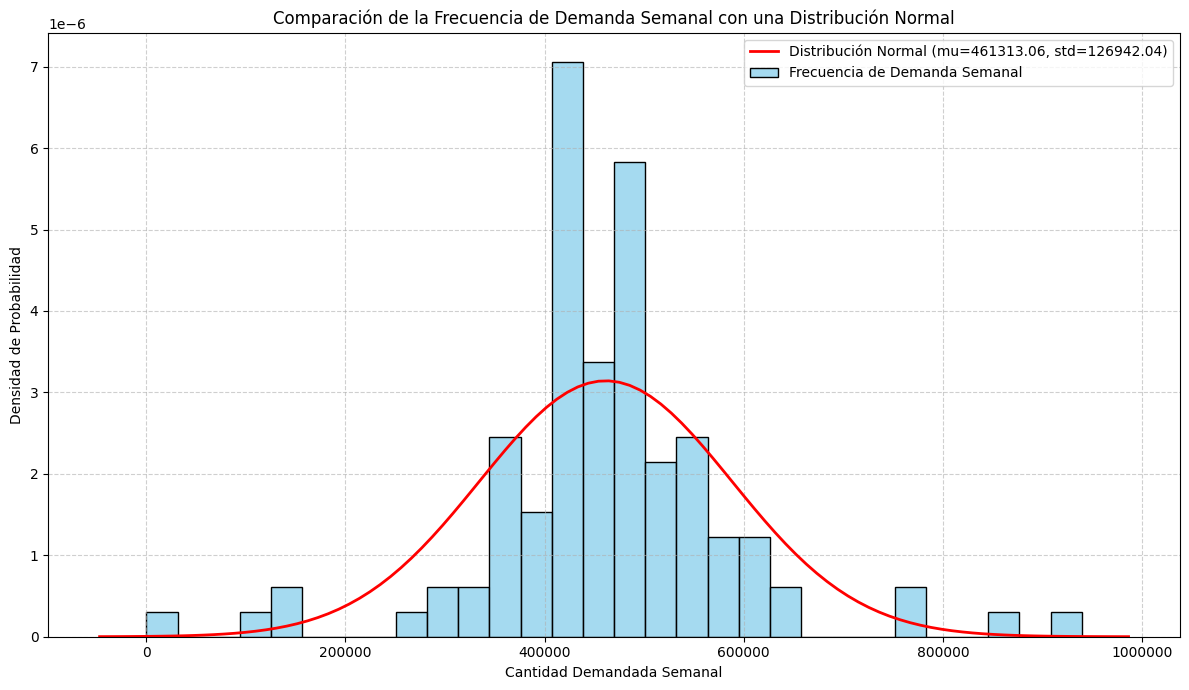


Estadísticas de la Demanda Semanal:
Media: 461313.06
Desviación Estándar: 127556.77
Mediana: 455097.00
Asimetría (Skewness): 0.17
Curtosis (Kurtosis): 4.26


In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import numpy as np

# Asegurarse de que df_weekly está disponible y tiene la columna 'Facturado'
# Si df_weekly no está definido en este punto, se debería cargar o crear.
# Asumiendo que df_weekly ya está definido desde celdas anteriores.
if 'df_weekly' not in locals():
    print("Error: 'df_weekly' DataFrame no encontrado. Por favor, asegúrate de que la celda que lo crea se ha ejecutado.")
else:
    demand_data = df_weekly['Facturado']

    # Filtrar valores cero si no son representativos de la demanda (opcional, pero ayuda a la visualización)
    # demand_data = demand_data[demand_data > 0]

    if demand_data.empty:
        print("No hay datos de demanda válidos para analizar.")
    else:
        # Calcular la media y desviación estándar para la distribución normal
        mu, std = norm.fit(demand_data)

        plt.figure(figsize=(12, 7))
        sns.histplot(demand_data, bins=30, kde=False, stat='density', color='skyblue', edgecolor='black', label='Frecuencia de Demanda Semanal')

        # Trazar la función de densidad de probabilidad (PDF) de la distribución normal
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mu, std)
        plt.plot(x, p, 'r', linewidth=2, label=f'Distribución Normal (mu={mu:.2f}, std={std:.2f})')

        plt.title('Comparación de la Frecuencia de Demanda Semanal con una Distribución Normal')
        plt.xlabel('Cantidad Demandada Semanal')
        plt.ylabel('Densidad de Probabilidad')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.ticklabel_format(style='plain', axis='x') # Ensure x-axis labels are not in scientific notation
        plt.tight_layout()
        plt.show()

        print(f"\nEstadísticas de la Demanda Semanal:")
        print(f"Media: {demand_data.mean():.2f}")
        print(f"Desviación Estándar: {demand_data.std():.2f}")
        print(f"Mediana: {demand_data.median():.2f}")
        print(f"Asimetría (Skewness): {demand_data.skew():.2f}")
        print(f"Curtosis (Kurtosis): {demand_data.kurt():.2f}")

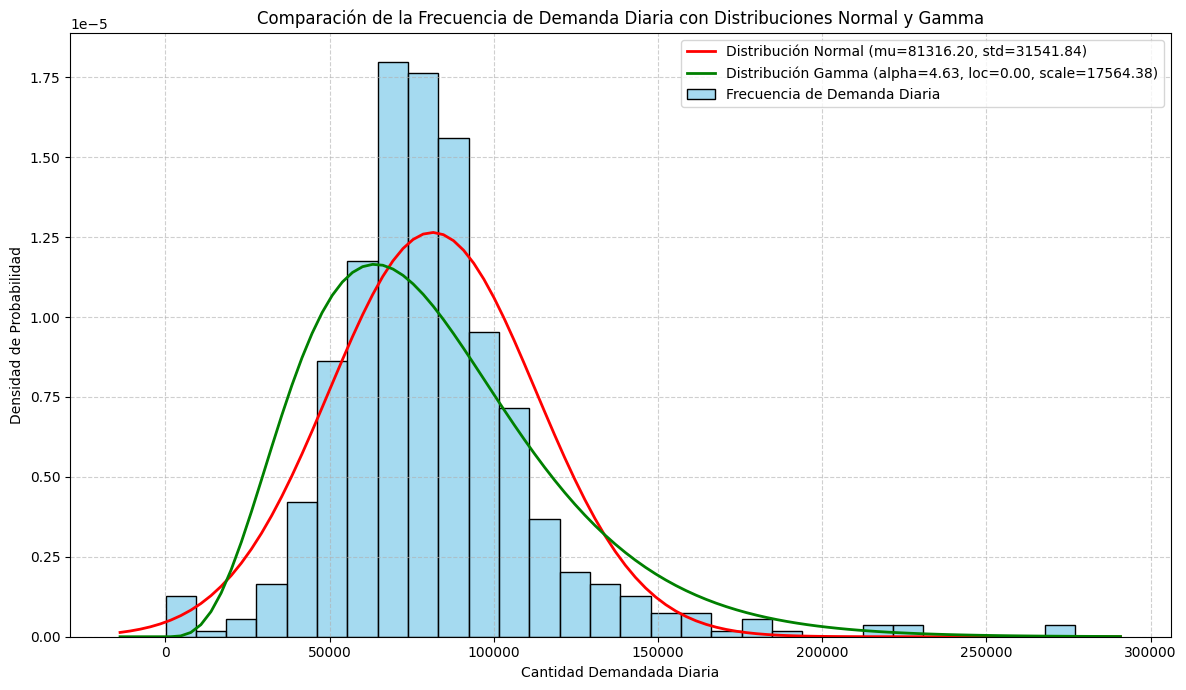


Estadísticas de la Demanda Diaria:
Media: 81316.20
Desviación Estándar: 31568.60
Mediana: 76653.50
Asimetría (Skewness): 1.62
Curtosis (Kurtosis): 7.05

Parámetros de ajuste de la Distribución Gamma:
  Alpha (forma): 4.63
  Loc (localización): 0.00
  Scale (escala): 17564.38


In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, gamma  # Import gamma distribution
import numpy as np

# Asegurarse de que df_ts está disponible y tiene la columna 'Facturado'
# Asumiendo que df_ts ya está definido desde celdas anteriores.
if 'df_ts' not in locals():
    print("Error: 'df_ts' DataFrame no encontrado. Por favor, asegúrate de que la celda que lo crea se ha ejecutado.")
else:
    # Re-muestrear a frecuencia diaria
    df_daily = df_ts.resample('D').agg({
        'Facturado': 'sum',     # volumen total diario (demanda)
        'VentaTotal': 'sum',    # valor total diario ($)
        'VlrUnitario': 'mean'   # precio promedio diario
    })
    df_daily = df_daily.fillna(0)

    demand_data = df_daily['Facturado']

    # Filtrar valores cero si no son representativos de la demanda (opcional, pero ayuda a la visualización)
    demand_data = demand_data[demand_data > 0] # It's generally better to fit distributions to non-zero demand if 0 represents no demand rather than actual 0 quantity.

    if demand_data.empty:
        print("No hay datos de demanda válidos para analizar.")
    else:
        # Calcular la media y desviación estándar para la distribución normal
        mu_norm, std_norm = norm.fit(demand_data)

        # Ajustar la distribución Gamma a los datos de demanda
        # floc=0 fija el parámetro de localización (loc) en 0, asumiendo que la demanda no puede ser negativa.
        alpha_gamma, loc_gamma, scale_gamma = gamma.fit(demand_data, floc=0)

        plt.figure(figsize=(12, 7))
        sns.histplot(demand_data, bins=30, kde=False, stat='density', color='skyblue', edgecolor='black', label='Frecuencia de Demanda Diaria')

        # Trazar la función de densidad de probabilidad (PDF) de la distribución normal
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p_norm = norm.pdf(x, mu_norm, std_norm)
        plt.plot(x, p_norm, 'r', linewidth=2, label=f'Distribución Normal (mu={mu_norm:.2f}, std={std_norm:.2f})')

        # Trazar la función de densidad de probabilidad (PDF) de la distribución Gamma
        p_gamma = gamma.pdf(x, alpha_gamma, loc_gamma, scale_gamma)
        plt.plot(x, p_gamma, 'g-', linewidth=2, label=f'Distribución Gamma (alpha={alpha_gamma:.2f}, loc={loc_gamma:.2f}, scale={scale_gamma:.2f})')

        plt.title('Comparación de la Frecuencia de Demanda Diaria con Distribuciones Normal y Gamma')
        plt.xlabel('Cantidad Demandada Diaria')
        plt.ylabel('Densidad de Probabilidad')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.ticklabel_format(style='plain', axis='x') # Ensure x-axis labels are not in scientific notation
        plt.tight_layout()
        plt.show()

        print(f"\nEstadísticas de la Demanda Diaria:")
        print(f"Media: {demand_data.mean():.2f}")
        print(f"Desviación Estándar: {demand_data.std():.2f}")
        print(f"Mediana: {demand_data.median():.2f}")
        print(f"Asimetría (Skewness): {demand_data.skew():.2f}")
        print(f"Curtosis (Kurtosis): {demand_data.kurt():.2f}")

        print(f"\nParámetros de ajuste de la Distribución Gamma:")
        print(f"  Alpha (forma): {alpha_gamma:.2f}")
        print(f"  Loc (localización): {loc_gamma:.2f}")
        print(f"  Scale (escala): {scale_gamma:.2f}")

### **IMPORTANTE**

Después del análisis exploratorio, y en conjunto con el equipo de analítica de datos, se debe definir qué **categorías o familias de productos** serán incluidas en el análisis final. Este proceso corresponde a una **reducción de dimensionalidad a nivel de negocio**, con el objetivo de trabajar sobre un subconjunto representativo y manejable computacionalmente.

A continuación, se proponen distintos métodos para la selección:

---

1. **Rentabilidad (maximización de ganancia)**

Prioriza productos con mayor margen o contribución a la utilidad.

**Ventajas:**
- Alinea el análisis con objetivos financieros  
- Permite optimizar decisiones orientadas a beneficio económico  

**Desventajas:**
- Puede ignorar productos de alto volumen pero bajo margen  
- Requiere información confiable de costos y márgenes  

---

2. **Costos (minimización de costos de inventario)**

Selecciona productos considerando su impacto en costos logísticos, almacenamiento y reposición.

**Ventajas:**
- Útil para optimización de inventarios  
- Reduce riesgos asociados a sobrestock o productos costosos  

**Desventajas:**
- Puede excluir productos relevantes en ventas  
- Depende de la calidad de la información de costos  

---

3. **Productos ancla**

Incluye productos que, aunque no necesariamente sean los más rentables, **generan tráfico, fidelización o ventas cruzadas**.

**Ventajas:**
- Refleja dinámicas reales de comportamiento del cliente  
- Importante en estrategias comerciales y de portafolio
- Permiten identificar comportamientos paralelos de demanda de diferentes productos dentro y entre categorias.

**Desventajas:**
- Difícil de identificar sin análisis previo
- Requiere validación con el negocio  

---

4. **Disponibilidad de datos**
Filtrar productos con suficiente historial y calidad de información (facturado, backroder, vlrunitario).

- Evita problemas en modelado  
- Mejora la confiabilidad de resultados  

---

## Consideración final

La selección de categorías no debe depender de un único criterio. Se recomienda utilizar una **combinación de métodos**, validada con el equipo de negocio, para asegurar que el conjunto final:

- Sea representativo
- Tenga impacto en el negocio
- Sea viable desde el punto de vista analítico